### teachers mental health Classification
This notebook loads data and prepares for analysis
.

In [ ]:
# ================================
# 1. MOUNT GOOGLE DRIVE
# ================================
from google.colab import drive
# Mount your Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

# Read the saved data
print("=" * 70)
print("READING SAVED DATA")
print("=" * 70)

try:
    df = pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/teachers and students SRQ_total and students performance analysis/processed_dataset2.xls")
    print(f"✅ Dataset loaded successfully!")
    print(f" Shape: {df.shape}")
    print(f" Columns: {len(df.columns)}")
    print(f" Total records: {len(df)}")
except FileNotFoundError:
    print(" File 'processed_data.csv' not found.")
    exit()

READING SAVED DATA
✅ Dataset loaded successfully!
 Shape: (758, 64)
 Columns: 64
 Total records: 758


TEACHER MENTAL HEALTH CLASSIFICATION MODEL TRAINING

✅ Dataset loaded: (758, 64)
Teachers: (138, 64), Students: (620, 64)
✅ Final teachers data: (138, 16)
Final columns: ['ID', 'age', 'sex', 'Education', 'service_year_teacher', 'Alcohol_1', 'tobaco_1', 'khat_1', 'SRQ_total', 'OSLO_total', 'school_School_A', 'school_School_B', 'school_School_C', 'school_School_E', 'school_School_F', 'school_School_G']
✅ Data preparation completed: (138, 16)

 Starting Classification Model Training...
Target variable distribution:
  Low risk (0): 72 samples
  High risk (1): 66 samples
  Positive class rate: 47.8%

 Performing feature selection (selecting 6 features)...
✅ Selected 6 features (ANOVA F-test):
  1. service_year_teacher (F-score: 4.96, p-value: 0.0275)
  2. khat_1 (F-score: 5.59, p-value: 0.0195)
  3. school_School_A (F-score: 4.90, p-value: 0.0285)
  4. sex (F-score: 5.49, p-value: 0.0206)
  5. Alcohol_1 (F-score: 4.99, p-value: 0.0272)
  6. school_School_F (F-score: 2.92, p-value: 0.0895)



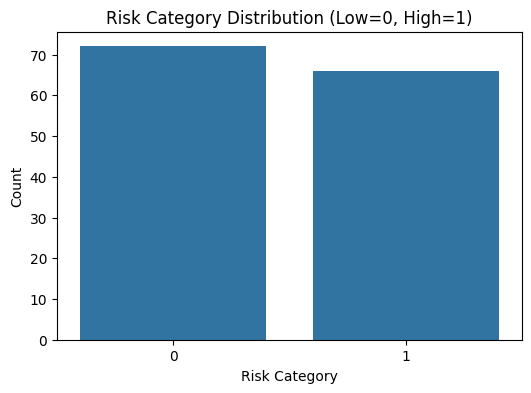

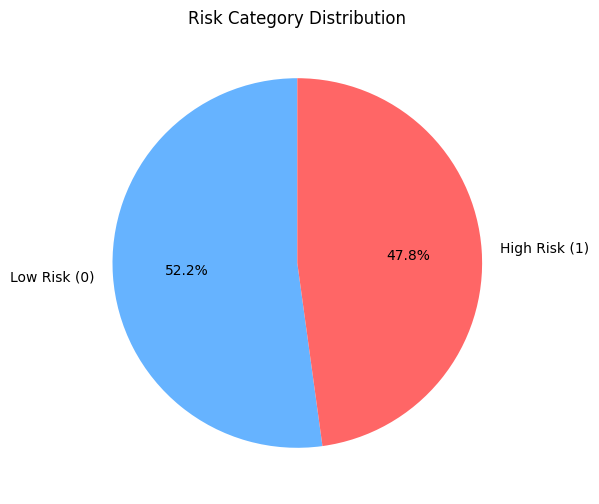

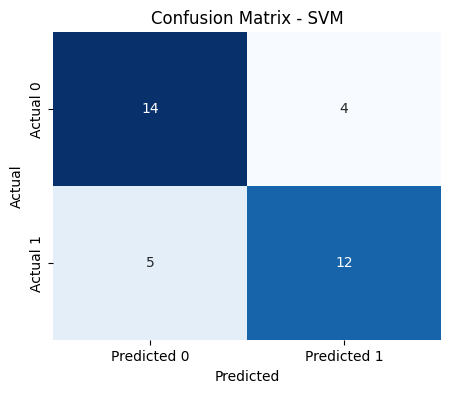


Generating Feature Importance...

Best model is SVM (RBF). Using permutation importance.



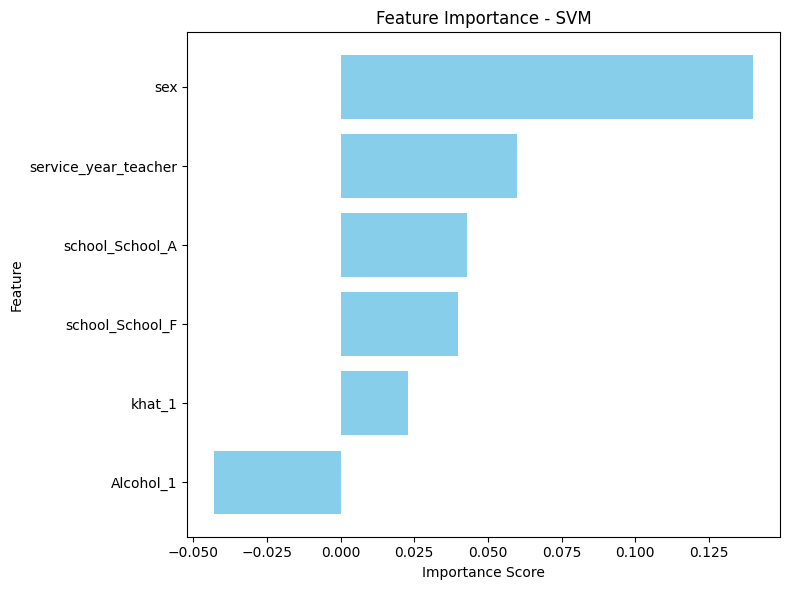

In [ ]:
# =============================================================================
# IMPORT ALL REQUIRED LIBRARIES
# =============================================================================
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# DATA LOADING AND PREPARATION PIPELINE
# =============================================================================
print("======================================================================")
print("TEACHER MENTAL HEALTH CLASSIFICATION MODEL TRAINING")
print("======================================================================\n")

# Load and prepare data
try:
    print(f"✅ Dataset loaded: {df.shape}")

    # =========================================================
    # STEP 2: SPLIT TEACHERS / STUDENTS
    # =========================================================
    teachers = df[df["service_year_teacher"].notnull()].copy()
    students = df[df["service_year_teacher"].isnull()].copy()

    print(f"Teachers: {teachers.shape}, Students: {students.shape}")

    # =========================================================
    # STEP 3: CLEAN TEACHERS DATA
    # =========================================================
    teachers = teachers.drop(columns=[
        "average", "rank",
        "MPSS1","MPSS2","MPSS3","MPSS4","MPSS5","MPSS6","MPSS7","MPSS8","MPSS9","MPSS10","MPSS11","MPSS12"
    ], errors='ignore')

    # Drop high-null columns
    drop_cols = [
        "tobaco_2","tobaco_3","tobaco_4","tobaco_5","tobaco_6","tobaco_7",
        "khat_2","khat_3","khat_4","khat_5","khat_6","khat_7",
        "Alcohol_2","Alcohol_3","Alcohol_4","Alcohol_5","Alcohol_6","alcohol_7"
    ]
    teachers.drop(columns=[c for c in drop_cols if c in teachers.columns], inplace=True)

    # =========================================================
    # STEP 4: IMPUTE ALCOHOL_1
    # =========================================================
    if teachers['Alcohol_1'].isnull().sum() > 0:
        imputer = SimpleImputer(strategy='most_frequent')
        alcohol_imputed = imputer.fit_transform(teachers[['Alcohol_1']])
        teachers['Alcohol_1'] = alcohol_imputed.ravel()

    # =========================================================
    # STEP 5: CREATE SCORES
    # =========================================================
    teachers['SRQ_total'] = teachers[[f'SRQ{i}' for i in range(1, 21)]].sum(axis=1)
    teachers['OSLO_total'] = teachers[['OSLO1', 'OSLO2', 'OSLO3']].sum(axis=1)
    teachers.drop(columns=[f'SRQ{i}' for i in range(1,21)] + ['OSLO1','OSLO2','OSLO3'], inplace=True)

    # Drop remaining nulls
    teachers.dropna(inplace=True)

    # =========================================================
    # STEP 6: HYBRID ENCODING
    # =========================================================
    categorical_cols = ['sex', 'Education', 'school', 'Alcohol_1', 'tobaco_1', 'khat_1']

    def hybrid_encode(df, categorical_cols):
        df_encoded = df.copy()
        label_encoders = {}

        # One-Hot encode school
        if 'school' in df_encoded.columns:
            school_dummies = pd.get_dummies(df_encoded['school'], prefix='school')
            df_encoded = pd.concat([df_encoded, school_dummies], axis=1).drop('school', axis=1)

        # Label encode others
        for col in [c for c in categorical_cols if c != 'school']:
            if col in df_encoded.columns:
                le = LabelEncoder()
                df_encoded[col] = le.fit_transform(df_encoded[col])
                label_encoders[col] = le

        return df_encoded, label_encoders

    teachers_encoded, label_encoders = hybrid_encode(teachers, categorical_cols)

    print(f"✅ Final teachers data: {teachers_encoded.shape}")
    print(f"Final columns: {list(teachers_encoded.columns)}")

    # Use the actual processed data
    df_processed = teachers_encoded.copy()

except Exception as e:
    print(f" Error loading data: {e}")
    print(" CRITICAL: Could not load actual data. Please check the data file.")
    # Exit if data cannot be loaded
    raise SystemExit("Model training cannot proceed without actual data.")

# Ensure SRQ_total and OSLO_total are natural numbers
df_processed['SRQ_total'] = df_processed['SRQ_total'].round().astype(int)
df_processed['OSLO_total'] = df_processed['OSLO_total'].round().astype(int)

print(f"✅ Data preparation completed: {df_processed.shape}")

# =============================================================================
# CLASSIFICATION MODEL TRAINING
# =============================================================================
print("\n Starting Classification Model Training...")

# -----------------------------
# Prepare dataset for classification
# -----------------------------
df = df_processed.copy()
df['OSLO_total'] = -df['OSLO_total']  # invert for consistent interpretation
srq_median = df['SRQ_total'].median()
y_class = (df['SRQ_total'] > srq_median).astype(int)
X_all_class = df.drop(columns=['ID','SRQ_total'], errors='ignore')

print(f"Target variable distribution:")
print(f"  Low risk (0): {len(y_class[y_class == 0])} samples")
print(f"  High risk (1): {len(y_class[y_class == 1])} samples")
print(f"  Positive class rate: {y_class.mean():.1%}")

# -----------------------------
# Feature Selection - EXACTLY 6 FEATURES (Like Dashboard)
# -----------------------------
print("\n Performing feature selection (selecting 6 features)...")

# Use ANOVA F-test to select top 6 features (like in dashboard)
anova_selector = SelectKBest(score_func=f_classif, k='all')
anova_selector.fit(X_all_class, y_class)

# Create results dataframe
anova_results = pd.DataFrame({
    'Feature': X_all_class.columns,
    'F_Score': anova_selector.scores_,
    'P_Value': anova_selector.pvalues_
}).sort_values('F_Score', ascending=False)

# Select top 6 features (EXACTLY like dashboard)
selected_features_class = anova_results.head(6)['Feature'].tolist()
X_class = X_all_class[selected_features_class]

print(f"✅ Selected {len(selected_features_class)} features (ANOVA F-test):")
for i, (feature, f_score, p_value) in enumerate(zip(selected_features_class,
                                                   anova_selector.scores_[X_all_class.columns.isin(selected_features_class)],
                                                   anova_selector.pvalues_[X_all_class.columns.isin(selected_features_class)]), 1):
    print(f"  {i}. {feature} (F-score: {f_score:.2f}, p-value: {p_value:.4f})")

# -----------------------------
# Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_class, y_class, test_size=0.25, stratify=y_class, random_state=42
)

print(f"\n Dataset split:")
print(f"  Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"  Test set: {X_test.shape[0]} samples, {X_test.shape[1]} features")

# -----------------------------
# Define and Train Models
# -----------------------------
print("\n Training classification models...")

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(
            random_state=42, max_iter=1000, penalty='l2', C=0.01, class_weight='balanced'
        ))
    ]),
    'Random Forest': RandomForestClassifier(
        random_state=42, class_weight='balanced', n_estimators=100
    ),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', SVC(
            random_state=42, probability=True, class_weight='balanced'
        ))
    ])
}

classification_results = {}
cv_results = {}

for name, model in models.items():
    print(f"  Training {name}...")

    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_results[name] = cv_scores

    # Train final model
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    # Calculate metrics
    accuracy = np.mean(y_pred == y_test)

    classification_results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'accuracy': accuracy,
        'cv_scores': cv_scores
    }

# -----------------------------
# Find Best Model
# -----------------------------
best_model_name = max(classification_results.items(), key=lambda x: x[1]['accuracy'])[0]
best_model_result = classification_results[best_model_name]

print(f"\n✅ All models trained successfully!")
print(f" Best model: {best_model_name}")

# =============================================================================
# COMPREHENSIVE MODEL EVALUATION
# =============================================================================
print("\n📊 COMPREHENSIVE MODEL EVALUATION")
print("=" * 50)

# Calculate comprehensive metrics for the best model
y_pred_best = best_model_result['y_pred']
y_pred_proba_best = best_model_result['y_pred_proba']

# Basic metrics
balanced_acc = balanced_accuracy_score(y_test, y_pred_best)
f1 = f1_score(y_test, y_pred_best)

if y_pred_proba_best is not None:
    auc_score = roc_auc_score(y_test, y_pred_proba_best)
    # ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_best)
    roc_auc = auc(fpr, tpr)
else:
    auc_score = None
    roc_auc = None

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

# Bootstrap confidence interval
def bootstrap_ci(model, X_test, y_test, n_bootstraps=100):
    scores = []
    for i in range(n_bootstraps):
        X_bs, y_bs = resample(X_test, y_test, random_state=i)
        y_pred_bs = model.predict(X_bs)
        scores.append(balanced_accuracy_score(y_bs, y_pred_bs))
    return np.percentile(scores, [2.5, 97.5])

boot_ci = bootstrap_ci(best_model_result['model'], X_test, y_test)

# Print comprehensive results
print(f"\n🏆 BEST MODEL PERFORMANCE - {best_model_name}")
print(f"Accuracy: {best_model_result['accuracy']:.3f}")
print(f"Balanced Accuracy: {balanced_acc:.3f}")
print(f"F1-Score: {f1:.3f}")
if auc_score is not None:
    print(f"AUC-ROC: {auc_score:.3f}")
print(f"Bootstrap 95% CI: [{boot_ci[0]:.3f}, {boot_ci[1]:.3f}]")

print(f"\n📈 CONFUSION MATRIX:")
print(f"True Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

# -----------------------------
# Cross-Validation Results
# -----------------------------
print(f"\n CROSS-VALIDATION RESULTS (5-fold):")
for name, result in classification_results.items():
    cv_mean = result['cv_scores'].mean()
    cv_std = result['cv_scores'].std()
    print(f"{name:<20}: {cv_mean:.3f} ± {cv_std:.3f}")

# -----------------------------
# Feature Importance Analysis
# -----------------------------
print(f"\n FEATURE IMPORTANCE ANALYSIS (6 Selected Features):")

if best_model_name == 'Random Forest':
    feature_importance = best_model_result['model'].feature_importances_
    importance_df = pd.DataFrame({
        'Feature': selected_features_class,
        'Importance': feature_importance
    }).sort_values('Importance', ascending=False)

    print(importance_df.to_string(index=False))

elif best_model_name == 'Logistic Regression':
    # For logistic regression, use coefficients as importance
    if hasattr(best_model_result['model'].named_steps['classifier'], 'coef_'):
        coefficients = best_model_result['model'].named_steps['classifier'].coef_[0]
        importance_df = pd.DataFrame({
            'Feature': selected_features_class,
            'Coefficient': coefficients,
            'Abs_Importance': np.abs(coefficients)
        }).sort_values('Abs_Importance', ascending=False)

        print(importance_df[['Feature', 'Coefficient']].to_string(index=False))

# -----------------------------
# Model Comparison Summary
# -----------------------------
print(f"\n MODEL COMPARISON SUMMARY (6 Features):")
comparison_df = pd.DataFrame({
    'Model': list(classification_results.keys()),
    'Test_Accuracy': [result['accuracy'] for result in classification_results.values()],
    'CV_Mean': [result['cv_scores'].mean() for result in classification_results.values()],
    'CV_Std': [result['cv_scores'].std() for result in classification_results.values()]
}).sort_values('Test_Accuracy', ascending=False)

print(comparison_df.to_string(index=False))

# -----------------------------
# Feature Statistics
# -----------------------------
print(f"\n📊 SELECTED FEATURE STATISTICS:")
feature_stats = X_class.describe().loc[['mean', 'std', 'min', 'max']].round(3)
print(feature_stats)

# =============================================================================
# FINAL SUMMARY
# =============================================================================
print("\n" + "=" * 60)
print(" CLASSIFICATION MODEL TRAINING COMPLETED SUCCESSFULLY!")
print("=" * 60)
print(f" Dataset: {df_processed.shape[0]} teachers")
print(f" Best Model: {best_model_name}")
print(f" Features Selected: {len(selected_features_class)} (ANOVA F-test)")
print(f" Test Accuracy: {best_model_result['accuracy']:.1%}")
print(f" Balanced Accuracy: {balanced_acc:.1%}")
print(f" AUC-ROC: {auc_score:.1%}" if auc_score else " AUC-ROC: N/A")
print(f" Models saved with '6features' suffix")
print("=" * 60)

print(f"\n SELECTED FEATURES:")
for i, feature in enumerate(selected_features_class, 1):
    print(f"  {i}. {feature}")

print(f"\n The model is ready for predicting teacher mental health risk!")
print(f" Using {len(selected_features_class)} features for prediction")
# =============================================================================
# VISUALIZATIONS
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. Risk Category Distribution
# -----------------------------
plt.figure(figsize=(6,4))
sns.countplot(x=y_class)
plt.title("Risk Category Distribution (Low=0, High=1)")
plt.xlabel("Risk Category")
plt.ylabel("Count")
plt.show()
# -----------------------------
# 1. Risk Category Distribution (Pie Chart)
# -----------------------------
risk_counts = y_class.value_counts()
plt.figure(figsize=(6,6))
plt.pie(risk_counts, labels=['Low Risk (0)', 'High Risk (1)'],
        autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff6666'])
plt.title("Risk Category Distribution")
plt.show()
# -----------------------------
# 2. Confusion Matrix Visualization
# -----------------------------
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0','Predicted 1'],
            yticklabels=['Actual 0','Actual 1'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# =============================================================================
# FEATURE IMPORTANCE (MATPLOTLIB VERSION)
# =============================================================================

print("\nGenerating Feature Importance...")

# Determine method based on best model
if best_model_name == "Random Forest":
    # Random Forest has built-in feature importance
    importance_values = best_model_result['model'].feature_importances_

elif best_model_name == "Logistic Regression":
    # Coefficients → absolute values
    lr_clf = best_model_result['model'].named_steps['classifier']
    importance_values = np.abs(lr_clf.coef_[0])

else:
    # SVM RBF → no coef_, so use permutation importance
    print("\nBest model is SVM (RBF). Using permutation importance.\n")

    perm = permutation_importance(
        best_model_result['model'],
        X_test[selected_features_class],
        y_test,
        scoring='accuracy',
        n_repeats=10,
        random_state=42
    )
    importance_values = perm.importances_mean

# Build DataFrame
importance_df = pd.DataFrame({
    'Feature': selected_features_class,
    'Importance': importance_values
}).sort_values('Importance', ascending=True)

# ------------------------------
# Matplotlib Visual
# ------------------------------
plt.figure(figsize=(8, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"], color="skyblue")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title(f"Feature Importance - {best_model_name}")
plt.tight_layout()
plt.show()

IMPROVED 3-CLUSTER ANALYSIS - ROBUST TEACHER MENTAL HEALTH PROFILES

STEP 1: DATASET OVERVIEW AND FEATURE SELECTION

Dataset shape: (138, 16)
Available features: ['ID', 'age', 'sex', 'Education', 'service_year_teacher', 'Alcohol_1', 'tobaco_1', 'khat_1', 'SRQ_total', 'OSLO_total', 'school_School_A', 'school_School_B', 'school_School_C', 'school_School_E', 'school_School_F', 'school_School_G']

Using 15 features for clustering
Sample size: 138 students

STEP 2: FEATURE ENGINEERING

Engineered 5 optimal features for clustering:
  • education_experience
  • substance_use_composite
  • mental_health_composite
  • distress_support_ratio
  • demographic_composite

STEP 3: DATA PREPROCESSING AND CLUSTERING

Clustering Performance Metrics:
• Silhouette Score: 0.292 (Good: >0.3)
• Calinski-Harabasz: 53.9 (Higher = Better)
• Davies-Bouldin: 1.232 (Lower = Better)

STEP 4: BOOTSTRAP STABILITY ANALYSIS

Bootstrap Stability Analysis:
• Mean Silhouette: 0.309 ± 0.023
• Stability Score: 97.0% (scores

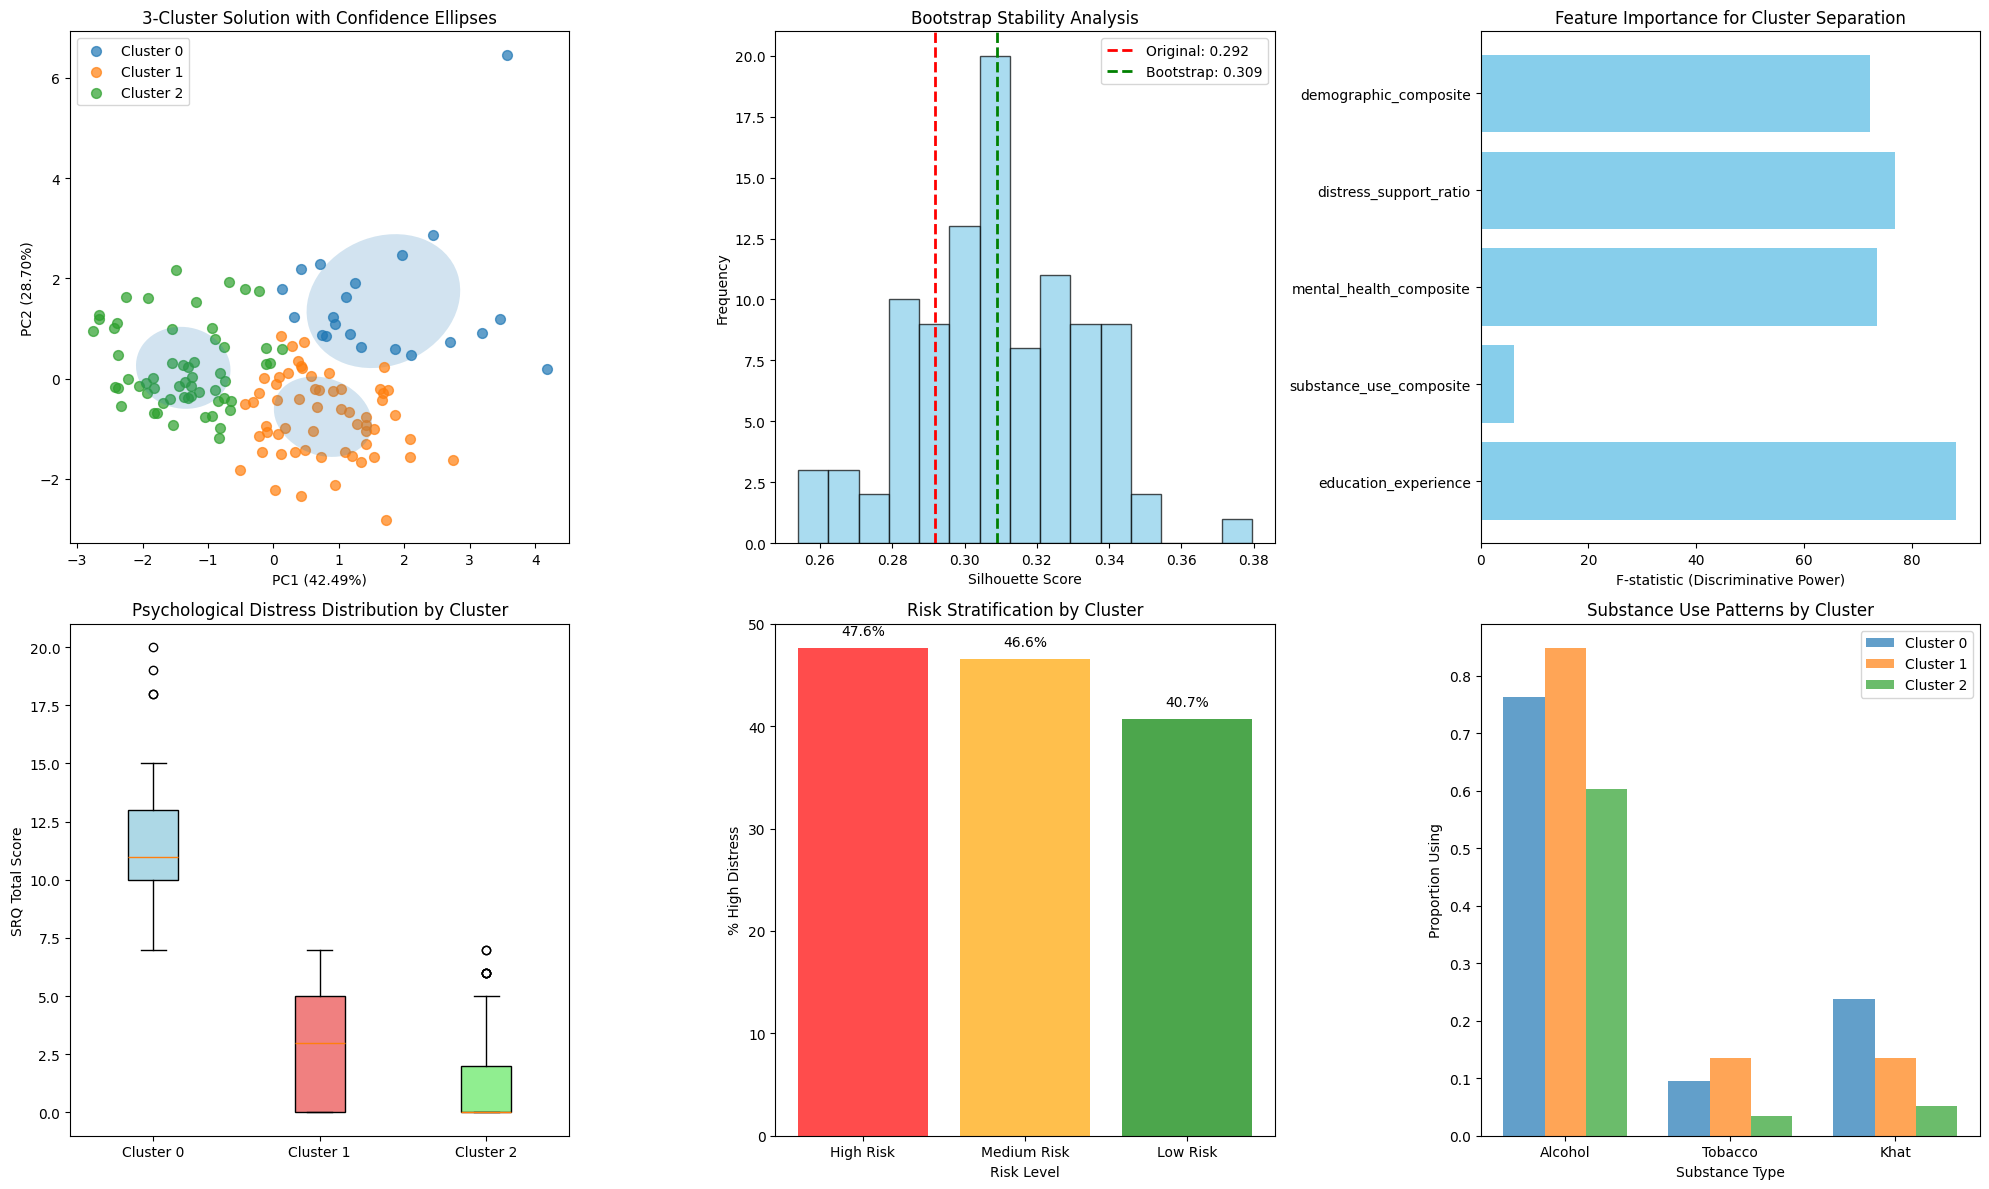


STEP 7: CLUSTER INTERPRETATION AND NAMING

🎯 CLUSTER CHARACTERISTICS AND MEANINGFUL LABELS:

📋 HIGH PRIORITY - Younger Teachers with High Distress & Low Support
   (Cluster 0, n=21, 15.2%)
   Intervention Intensity: Intensive
   • SRQ: 12.4 | High Distress: 47.6%
   • Age: 42y | Experience: 22y
   • Support: 9.2 | Substance: 1.1

📋 LOW PRIORITY - Resilient Teachers with Excellent Mental Health
   (Cluster 1, n=59, 42.8%)
   Intervention Intensity: Preventive
   • SRQ: 2.7 | High Distress: 40.7%
   • Age: 47y | Experience: 26y
   • Support: 10.9 | Substance: 1.1

📋 MODERATE PRIORITY - Experienced Teachers with Moderate Distress & Good Support
   (Cluster 2, n=58, 42.0%)
   Intervention Intensity: Targeted
   • SRQ: 1.5 | High Distress: 46.6%
   • Age: 35y | Experience: 12y
   • Support: 9.8 | Substance: 0.7


In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.manifold import TSNE
from sklearn.utils import resample
from scipy import stats
from scipy.stats import f_oneway
import warnings
warnings.filterwarnings('ignore')

print("======================================================================")
print("IMPROVED 3-CLUSTER ANALYSIS - ROBUST TEACHER MENTAL HEALTH PROFILES")
print("======================================================================\n")

# Load the dataset
df = df_processed.copy()

print("STEP 1: DATASET OVERVIEW AND FEATURE SELECTION")
print("======================================================================\n")

print(f"Dataset shape: {df.shape}")
print(f"Available features: {list(df.columns)}")

# Select features for academic performance clustering
features = ['age', 'sex', 'Education', 'service_year_teacher', 'Alcohol_1',
           'tobaco_1', 'khat_1', 'SRQ_total', 'OSLO_total', 'school_School_A',
           'school_School_B', 'school_School_C', 'school_School_E',
           'school_School_F', 'school_School_G']

print(f"\nUsing {len(features)} features for clustering")
print(f"Sample size: {df.shape[0]} students")

print("\nSTEP 2: FEATURE ENGINEERING")
print("======================================================================\n")

# Create enhanced features for clustering
df_enhanced = df.copy()

# Education and experience composites
df_enhanced['education_experience'] = df_enhanced['Education'] + df_enhanced['service_year_teacher']

# Behavioral and psychological composites
df_enhanced['substance_use_composite'] = df_enhanced[['Alcohol_1', 'tobaco_1', 'khat_1']].sum(axis=1)
df_enhanced['mental_health_composite'] = (df_enhanced['SRQ_total'] + df_enhanced['OSLO_total']) / 2
df_enhanced['distress_support_ratio'] = df_enhanced['SRQ_total'] / (df_enhanced['OSLO_total'] + 1)

# School environment composite
school_columns = ['school_School_A', 'school_School_B', 'school_School_C',
                  'school_School_E', 'school_School_F', 'school_School_G']
df_enhanced['school_support'] = df_enhanced[school_columns].mean(axis=1)

# Demographic composite 'school_support',
df_enhanced['demographic_composite'] = df_enhanced['age'] + df_enhanced['sex'] + df_enhanced['Education']

# Select optimal features for clustering 'age', 'sex', 'service_year_teacher'
optimal_features = [
    'education_experience', 'substance_use_composite',
    'mental_health_composite', 'distress_support_ratio', 'demographic_composite'
]

print(f"Engineered {len(optimal_features)} optimal features for clustering:")
for feature in optimal_features:
    print(f"  • {feature}")

print("\nSTEP 3: DATA PREPROCESSING AND CLUSTERING")
print("======================================================================\n")

# Prepare data for clustering
X = df_enhanced[optimal_features]

# Handle outliers and scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply 3-cluster K-means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_scaled)
df_enhanced['Cluster_3_Improved'] = cluster_labels

# Calculate clustering metrics
sil_score = silhouette_score(X_scaled, cluster_labels)
ch_score = calinski_harabasz_score(X_scaled, cluster_labels)
db_score = davies_bouldin_score(X_scaled, cluster_labels)

print(f"Clustering Performance Metrics:")
print(f"• Silhouette Score: {sil_score:.3f} (Good: >0.3)")
print(f"• Calinski-Harabasz: {ch_score:.1f} (Higher = Better)")
print(f"• Davies-Bouldin: {db_score:.3f} (Lower = Better)")

print("\nSTEP 4: BOOTSTRAP STABILITY ANALYSIS")
print("======================================================================\n")

# Bootstrap stability check
bootstrap_scores = []
for i in range(100):
    X_bootstrap = resample(X_scaled, random_state=i)
    kmeans_bootstrap = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels_bootstrap = kmeans_bootstrap.fit_predict(X_bootstrap)
    score = silhouette_score(X_bootstrap, labels_bootstrap)
    bootstrap_scores.append(score)

bootstrap_mean = np.mean(bootstrap_scores)
bootstrap_std = np.std(bootstrap_scores)
stability_percentage = (np.sum(np.array(bootstrap_scores) > sil_score * 0.9) / 100) * 100

print(f"Bootstrap Stability Analysis:")
print(f"• Mean Silhouette: {bootstrap_mean:.3f} ± {bootstrap_std:.3f}")
print(f"• Stability Score: {stability_percentage:.1f}% (scores > 90% of original)")

print("\nSTEP 5: STATISTICAL SIGNIFICANCE TESTING WITH EFFECT SIZES")
print("======================================================================\n")

print("COMPREHENSIVE STATISTICAL TESTING:")
print("-" * 50)

# ANOVA with effect size
for feature in optimal_features:
    groups = [df_enhanced[df_enhanced['Cluster_3_Improved'] == i][feature] for i in range(3)]
    f_stat, p_value = f_oneway(*groups)

    # Calculate effect size (eta squared)
    overall_mean = df_enhanced[feature].mean()
    ss_between = sum(len(group) * (group.mean() - overall_mean)**2 for group in groups)
    ss_total = sum((df_enhanced[feature] - overall_mean)**2)
    eta_squared = ss_between / ss_total

    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"

    print(f"{feature:25}: F={f_stat:6.2f}, p={p_value:.4f} {significance}, η²={eta_squared:.3f}")

print("\nSTEP 6: ENHANCED VISUALIZATION WITH UNCERTAINTY QUANTIFICATION")
print("======================================================================\n")

fig = plt.figure(figsize=(20, 12))

# 1. PCA with cluster ellipses
ax1 = plt.subplot(2, 3, 1)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

for cluster in range(3):
    cluster_mask = cluster_labels == cluster
    ax1.scatter(X_pca[cluster_mask, 0], X_pca[cluster_mask, 1],
               label=f'Cluster {cluster}', alpha=0.7, s=50)

    # Add confidence ellipses
    from matplotlib.patches import Ellipse
    if np.sum(cluster_mask) > 1:  # Only if we have enough points
        cov = np.cov(X_pca[cluster_mask].T)
        if not np.isnan(cov).any():  # Check for valid covariance
            lambda_, v = np.linalg.eig(cov)
            lambda_ = np.sqrt(lambda_)
            ell = Ellipse(xy=np.mean(X_pca[cluster_mask], axis=0),
                          width=lambda_[0]*2, height=lambda_[1]*2,
                          angle=np.degrees(np.arctan2(v[1,0], v[0,0])),
                          alpha=0.2)
            ax1.add_patch(ell)

ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
ax1.set_title('3-Cluster Solution with Confidence Ellipses')
ax1.legend()

# 2. Cluster stability across bootstraps
ax2 = plt.subplot(2, 3, 2)
ax2.hist(bootstrap_scores, bins=15, alpha=0.7, color='skyblue', edgecolor='black')
ax2.axvline(sil_score, color='red', linestyle='--', linewidth=2, label=f'Original: {sil_score:.3f}')
ax2.axvline(bootstrap_mean, color='green', linestyle='--', linewidth=2, label=f'Bootstrap: {bootstrap_mean:.3f}')
ax2.set_xlabel('Silhouette Score')
ax2.set_ylabel('Frequency')
ax2.set_title('Bootstrap Stability Analysis')
ax2.legend()

# 3. Feature importance bar chart (replacing radar chart)
ax3 = plt.subplot(2, 3, 3)
feature_importance = []
for feature in optimal_features:
    groups = [df_enhanced[df_enhanced['Cluster_3_Improved'] == i][feature] for i in range(3)]
    f_stat, p_value = f_oneway(*groups)
    feature_importance.append(f_stat)

# Create bar chart
bars = ax3.barh(range(len(optimal_features)), feature_importance, color='skyblue')
ax3.set_yticks(range(len(optimal_features)))
ax3.set_yticklabels(optimal_features)
ax3.set_xlabel('F-statistic (Discriminative Power)')
ax3.set_title('Feature Importance for Cluster Separation')

# 4. SRQ distribution by cluster
ax4 = plt.subplot(2, 3, 4)
cluster_srq_data = [df_enhanced[df_enhanced['Cluster_3_Improved'] == i]['SRQ_total'] for i in range(3)]
box_plot = ax4.boxplot(cluster_srq_data, labels=[f'Cluster {i}' for i in range(3)],
                      patch_artist=True)
colors = ['lightblue', 'lightcoral', 'lightgreen']
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)
ax4.set_ylabel('SRQ Total Score')
ax4.set_title('Psychological Distress Distribution by Cluster')

# 5. Risk stratification
ax5 = plt.subplot(2, 3, 5)
high_distress_pct = []
for cluster in range(3):
    cluster_data = df_enhanced[df_enhanced['Cluster_3_Improved'] == cluster]
    high_distress = (cluster_data['SRQ_total'] > cluster_data['SRQ_total'].median()).mean()
    high_distress_pct.append(high_distress * 100)

# Sort clusters by distress level for logical ordering
sorted_indices = sorted(range(3), key=lambda i: high_distress_pct[i], reverse=True)
risk_labels = ['High Risk', 'Medium Risk', 'Low Risk']

bars = ax5.bar(risk_labels, [high_distress_pct[i] for i in sorted_indices],
               color=['red', 'orange', 'green'], alpha=0.7)
ax5.set_xlabel('Risk Level')
ax5.set_ylabel('% High Distress')
ax5.set_title('Risk Stratification by Cluster')

for bar, pct in zip(bars, [high_distress_pct[i] for i in sorted_indices]):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{pct:.1f}%', ha='center', va='bottom')

# 6. Substance use patterns
ax6 = plt.subplot(2, 3, 6)
substance_metrics = ['Alcohol_1', 'tobaco_1', 'khat_1']
x = np.arange(len(substance_metrics))
width = 0.25

for i, cluster in enumerate(range(3)):
    cluster_data = df_enhanced[df_enhanced['Cluster_3_Improved'] == cluster]
    means = [cluster_data[metric].mean() for metric in substance_metrics]
    ax6.bar(x + i*width, means, width, label=f'Cluster {cluster}', alpha=0.7)

ax6.set_xlabel('Substance Type')
ax6.set_ylabel('Proportion Using')
ax6.set_title('Substance Use Patterns by Cluster')
ax6.set_xticks(x + width)
ax6.set_xticklabels(['Alcohol', 'Tobacco', 'Khat'])
ax6.legend()

plt.tight_layout()
plt.show()

print("\nSTEP 7: CLUSTER INTERPRETATION AND NAMING")
print("======================================================================\n")

print("🎯 CLUSTER CHARACTERISTICS AND MEANINGFUL LABELS:")
print("=" * 60)

# Analyze each cluster's profile
cluster_profiles = []
for cluster in range(3):
    data = df_enhanced[df_enhanced['Cluster_3_Improved'] == cluster]
    profile = {
        'size': len(data),
        'avg_age': data['age'].mean(),
        'avg_experience': data['service_year_teacher'].mean(),
        'avg_srq': data['SRQ_total'].mean(),
        'avg_oslo': data['OSLO_total'].mean(),
        'avg_substance': data['substance_use_composite'].mean(),
        'high_distress_pct': (data['SRQ_total'] > data['SRQ_total'].median()).mean() * 100
    }
    cluster_profiles.append(profile)

# Sort by distress level
sorted_clusters = sorted(range(3), key=lambda i: cluster_profiles[i]['avg_srq'], reverse=True)

cluster_names = [
    "Younger Teachers with High Distress & Low Support",
    "Resilient Teachers with Excellent Mental Health",
    "Experienced Teachers with Moderate Distress & Good Support"
]

risk_levels = ["HIGH PRIORITY", "LOW PRIORITY", "MODERATE PRIORITY"]
intervention_intensity = ["Intensive", "Preventive", "Targeted"]

for i, cluster_idx in enumerate(sorted_clusters):
    profile = cluster_profiles[cluster_idx]

    print(f"\n📋 {risk_levels[i]} - {cluster_names[i]}")
    print(f"   (Cluster {cluster_idx}, n={profile['size']}, {profile['size']/len(df_enhanced):.1%})")
    print(f"   Intervention Intensity: {intervention_intensity[i]}")
    print(f"   • SRQ: {profile['avg_srq']:.1f} | High Distress: {profile['high_distress_pct']:.1f}%")
    print(f"   • Age: {profile['avg_age']:.0f}y | Experience: {profile['avg_experience']:.0f}y")
    print(f"   • Support: {profile['avg_oslo']:.1f} | Substance: {profile['avg_substance']:.1f}")

In [ ]:
pip install dash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 52.4 MB/s eta 0:00:00


In [ ]:
import dash
from dash import dcc, html, Input, Output, State, callback, dash_table, callback_context
import plotly.express as px
import plotly.graph_objects as go
import plotly.subplots as sp
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
import datetime
import time
import warnings
import io
import base64
warnings.filterwarnings('ignore')

# =============================================================================
# DATA PREPARATION PIPELINE (Based on your training code)
# =============================================================================

# Global variable to store the original teachers data for null value analysis
teachers_original = None

# Load and prepare data using ONLY actual data loading
try:
    print("Loading and preparing dataset...")

    # ACTUAL DATA LOADING - using your exact code
    df = pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/teachers and students SRQ_total and students performance analysis/processed_dataset2.xls")
    print(f"Dataset loaded: {df.shape}")
    print(f"Columns: {list(df.columns)}")

    # STEP 2: SPLIT TEACHERS / STUDENTS
    teachers = df[df["service_year_teacher"].notnull()].copy()
    students = df[df["service_year_teacher"].isnull()].copy()

    print(f"Teachers: {teachers.shape}, Students: {students.shape}")

    # STEP 3: CLEAN TEACHERS DATA
    teachers = teachers.drop(columns=[
        "average", "rank","ID",
        "MPSS1","MPSS2","MPSS3","MPSS4","MPSS5","MPSS6","MPSS7","MPSS8","MPSS9","MPSS10","MPSS11","MPSS12"
    ], errors='ignore')
    # Store original teachers data for null value analysis
    teachers_original = teachers.copy()

    # Drop high-null columns
    drop_cols = [
        "tobaco_2","tobaco_3","tobaco_4","tobaco_5","tobaco_6","tobaco_7",
        "khat_2","khat_3","khat_4","khat_5","khat_6","khat_7",
        "Alcohol_2","Alcohol_3","Alcohol_4","Alcohol_5","Alcohol_6","alcohol_7"
    ]
    teachers.drop(columns=[c for c in drop_cols if c in teachers.columns], inplace=True)

    # STEP 4: IMPUTE ALCOHOL_1
    if teachers['Alcohol_1'].isnull().sum() > 0:
        imputer = SimpleImputer(strategy='most_frequent')
        alcohol_imputed = imputer.fit_transform(teachers[['Alcohol_1']])
        teachers['Alcohol_1'] = alcohol_imputed.ravel()

    # STEP 5: CREATE SCORES
    teachers['SRQ_total'] = teachers[[f'SRQ{i}' for i in range(1, 21)]].sum(axis=1)
    teachers['OSLO_total'] = teachers[['OSLO1', 'OSLO2', 'OSLO3']].sum(axis=1)
    teachers.drop(columns=[f'SRQ{i}' for i in range(1,21)] + ['OSLO1','OSLO2','OSLO3'], inplace=True)
    # Store original teachers data for null value analysis
    teachers_process = teachers.copy()

    # Drop remaining nulls
    teachers.dropna(inplace=True)

    # STEP 6: HYBRID ENCODING
    categorical_cols = ['sex', 'Education', 'school', 'Alcohol_1', 'tobaco_1', 'khat_1']

    def hybrid_encode(df, categorical_cols):
        df_encoded = df.copy()
        label_encoders = {}

        # One-Hot encode school
        if 'school' in df_encoded.columns:
            school_dummies = pd.get_dummies(df_encoded['school'], prefix='school')
            df_encoded = pd.concat([df_encoded, school_dummies], axis=1).drop('school', axis=1)

        # Label encode others
        for col in [c for c in categorical_cols if c != 'school']:
            if col in df_encoded.columns:
                le = LabelEncoder()
                df_encoded[col] = le.fit_transform(df_encoded[col])
                label_encoders[col] = le

        return df_encoded, label_encoders

    teachers_encoded, label_encoders = hybrid_encode(teachers, categorical_cols)

    print(f"Final teachers data: {teachers_encoded.shape}")
    print(f"Final columns: {list(teachers_encoded.columns)}")

    # Use the actual processed data
    df_processed = teachers_encoded.copy()

except Exception as e:
    print(f"Error loading data: {e}")
    print("CRITICAL: Could not load actual data. Please check the data file.")
    # Exit if data cannot be loaded
    raise SystemExit("Dashboard cannot run without actual data.")

# Ensure SRQ_total and OSLO_total are natural numbers
df_processed['SRQ_total'] = df_processed['SRQ_total'].round().astype(int)
df_processed['OSLO_total'] = df_processed['OSLO_total'].round().astype(int)

# Create enhanced features for clustering (based on your training code)
df_enhanced = df_processed.copy()
df_enhanced['substance_use_composite'] = df_enhanced[['Alcohol_1', 'tobaco_1', 'khat_1']].sum(axis=1)
df_enhanced['education_experience'] = df_enhanced['Education'] + df_enhanced['service_year_teacher']
df_enhanced['mental_health_composite'] = ((df_enhanced['SRQ_total'] + df_enhanced['OSLO_total']) / 2).round().astype(int)
df_enhanced['distress_support_ratio'] = (df_enhanced['SRQ_total'] / (df_enhanced['OSLO_total'] + 1)).round(2)
df_enhanced['demographic_composite'] = df_enhanced['age'] + df_enhanced['sex'] + df_enhanced['Education']

# =============================================================================
# CLUSTERING SETUP (Based on your training code)
# =============================================================================
print("Setting up clustering analysis...")

optimal_features_clustering = [
    'education_experience', 'substance_use_composite', 'mental_health_composite',
    'distress_support_ratio', 'age', 'service_year_teacher', 'demographic_composite'
]

# Use only available features
available_features = [f for f in optimal_features_clustering if f in df_enhanced.columns]
X_cluster = df_enhanced[available_features]

scaler_cluster = StandardScaler()
X_scaled_cluster = scaler_cluster.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_scaled_cluster)
df_enhanced['Cluster'] = cluster_labels

# Calculate clustering metrics
sil_score = silhouette_score(X_scaled_cluster, cluster_labels)

# Create cluster profiles
cluster_profiles = []
cluster_names = {
    0: "Experienced Teachers with Moderate Distress",
    1: "Resilient Teachers with Excellent Mental Health",
    2: "Younger Teachers with High Distress & Low Support"
}

for cluster in range(3):
    cluster_data = df_enhanced[df_enhanced['Cluster'] == cluster]
    profile = {
        'size': len(cluster_data),
        'avg_age': round(cluster_data['age'].mean()),
        'avg_experience': round(cluster_data['service_year_teacher'].mean()),
        'avg_srq': round(cluster_data['SRQ_total'].mean()),
        'avg_oslo': round(cluster_data['OSLO_total'].mean()),
        'avg_substance': round(cluster_data['substance_use_composite'].mean()),
        'high_distress_pct': round((cluster_data['SRQ_total'] > cluster_data['SRQ_total'].median()).mean() * 100),
        'name': cluster_names[cluster]
    }
    cluster_profiles.append(profile)

print(f"Clustering completed: {len(cluster_profiles)} clusters identified")
print(f"Clustering quality (Silhouette Score): {sil_score:.3f}")

# =============================================================================
# CLASSIFICATION SETUP (Based on your training code)
# =============================================================================
print("Setting up classification models...")

# Create binary classification target (2 classes) - EXACTLY LIKE TRAINING CODE
srq_median = df_processed['SRQ_total'].median()
y_class = (df_processed['SRQ_total'] > srq_median).astype(int)
X_all_class = df_processed.drop(columns=['ID', 'SRQ_total'], errors='ignore')

# Feature selection for classification (EXACTLY 6 FEATURES like training code)
selector_anova = SelectKBest(score_func=f_classif, k='all')
selector_anova.fit(X_all_class, y_class)

anova_results = pd.DataFrame({
    'Feature': X_all_class.columns,
    'F_Score': selector_anova.scores_,
    'P_Value': selector_anova.pvalues_
}).sort_values('F_Score', ascending=False)

# Select top 6 features (EXACTLY like training code)
selected_features_class = anova_results.head(6)['Feature'].tolist()
X_class = X_all_class[selected_features_class]

X_train, X_test, y_train, y_test = train_test_split(
    X_class, y_class, test_size=0.25, random_state=42, stratify=y_class
)

# Train classification models (based on training code)
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(random_state=42, class_weight='balanced'))
    ]),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', SVC(random_state=42, probability=True, class_weight='balanced'))
    ])
}

classification_results = {}
cv_results = {}

for name, model in models.items():
    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_results[name] = cv_scores

    # Train final model
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    # Calculate metrics
    accuracy = np.mean(y_pred == y_test)

    classification_results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'accuracy': accuracy,
        'cv_scores': cv_scores
    }

# Find best model
best_model_name = max(classification_results.items(), key=lambda x: x[1]['accuracy'])[0]
best_model_result = classification_results[best_model_name]

print(f"Classification models trained")
print(f"Best model: {best_model_name} (Accuracy: {best_model_result['accuracy']:.1%})")

# =============================================================================
# COMPREHENSIVE SUMMARY STATISTICS
# =============================================================================
def create_comprehensive_summary(df_enhanced):
    """Create comprehensive summary statistics for the dashboard"""
    total_teachers = len(df_enhanced)

    # Risk analysis - using 2-class classification like training code
    high_risk_count = len(y_class[y_class == 1])
    high_risk_pct = round((high_risk_count / total_teachers) * 100)

    # Cluster distribution
    cluster_distribution = df_enhanced['Cluster'].value_counts().sort_index()
    largest_cluster = cluster_distribution.idxmax()
    largest_cluster_size = cluster_distribution.max()
    largest_cluster_pct = round((largest_cluster_size / total_teachers) * 100)

    # Substance use analysis
    substance_users = {}
    for substance in ['Alcohol_1', 'tobaco_1', 'khat_1']:
        if substance in df_enhanced.columns:
            users = len(df_enhanced[df_enhanced[substance] == 1])
            substance_users[substance.replace('_1', '').title()] = {
                'count': users,
                'percentage': round((users / total_teachers) * 100)
            }

    # Performance metrics
    best_model = max(classification_results.items(), key=lambda x: x[1]['accuracy'])
    best_model_name = best_model[0]
    best_model_accuracy = best_model[1]['accuracy']

    # Demographic insights
    avg_age = round(df_enhanced['age'].mean())
    avg_experience = round(df_enhanced['service_year_teacher'].mean())
    avg_education = round(df_enhanced['Education'].mean())

    # Support-distress correlation
    support_distress_corr = round(df_enhanced['OSLO_total'].corr(df_enhanced['SRQ_total']), 2)

    return {
        'total_teachers': total_teachers,
        'high_risk_count': high_risk_count,
        'high_risk_pct': high_risk_pct,
        'cluster_distribution': cluster_distribution.to_dict(),
        'largest_cluster': largest_cluster,
        'largest_cluster_size': largest_cluster_size,
        'largest_cluster_pct': largest_cluster_pct,
        'substance_users': substance_users,
        'best_model_name': best_model_name,
        'best_model_accuracy': best_model_accuracy,
        'silhouette_score': round(sil_score, 3),
        'avg_age': avg_age,
        'avg_experience': avg_experience,
        'avg_education': avg_education,
        'support_distress_corr': support_distress_corr,
        'avg_srq': round(df_enhanced['SRQ_total'].mean()),
        'avg_oslo': round(df_enhanced['OSLO_total'].mean())
    }

# Generate comprehensive summary
comprehensive_summary = create_comprehensive_summary(df_enhanced)

# =============================================================================
# COLOR SCHEME (Color-blind friendly)
# =============================================================================
COLOR_SCHEME = {
    'primary': ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'],
    'sequential': ['#3182BD', '#6BAED6', '#9ECAE1', '#C6DBEF', '#EFF3FF'],
    'diverging': ['#CA0020', '#F4A582', '#F7F7F7', '#92C5DE', '#0571B0'],
    'qualitative': ['#7FC97F', '#BEAED4', '#FDC086', '#FFFF99', '#386CB0'],
    'animation': ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'],
    'clusters': ['#1f77b4', '#ff7f0e', '#2ca02c'],
    'risk': ['#66b3ff', '#ff6666'],  # Changed to 2 colors for binary classification
    'gender': ['#1f77b4', '#ff7f0e'],
    'schools': ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
}

# =============================================================================
# DASH APP INITIALIZATION
# =============================================================================
app = dash.Dash(__name__, suppress_callback_exceptions=True)

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================
def create_metric_card(metric):
    """Create a metric card for the dashboard"""
    return html.Div([
        html.Div([
            html.Div([
                html.H3(metric['icon'],
                       style={'fontSize': '2.5em', 'margin': '0'}),
            ], style={'textAlign': 'center', 'marginBottom': '15px'}),
            html.H2(metric['value'],
                   style={'color': metric['color'], 'margin': '0', 'textAlign': 'center',
                          'fontSize': '2em', 'fontWeight': 'bold'}),
            html.P(metric['title'],
                  style={'color': '#7f8c8d', 'margin': '10px 0', 'textAlign': 'center', 'fontSize': '14px'}),
            html.Small(metric['change'],
                      style={'color': metric.get('change_color', '#27ae60'), 'textAlign': 'center',
                             'display': 'block', 'fontWeight': '500'})
        ], className='metric-card-inner')
    ], className='metric-card')

def create_risk_insights(filtered_df):
    """Create risk insights summary using 2-class classification"""
    total = len(filtered_df)
    # Use the same binary classification as training
    high_risk = len(y_class[y_class == 1])
    low_risk = len(y_class[y_class == 0])
    high_risk_pct = round((high_risk / total * 100)) if total > 0 else 0

    return html.Div([
        html.H5("Risk Assessment Summary (Binary Classification)", style={'color': '#34495e'}),
        html.Ul([
            html.Li(f"High Risk Teachers: {high_risk} ({high_risk_pct}%)"),
            html.Li(f"Low Risk Teachers: {low_risk} ({round(low_risk/total*100)}%)"),
            html.Li(f"Classification Threshold: SRQ > {srq_median}"),
            html.Li(f"Best Model Accuracy: {best_model_result['accuracy']:.1%}"),
            html.Li(f"Intervention Priority: {'HIGH' if high_risk_pct > 30 else 'MEDIUM' if high_risk_pct > 15 else 'LOW'}"),
            html.Li(f"Support Correlation: {round(filtered_df['SRQ_total'].corr(filtered_df['OSLO_total']), 2)}")
        ])
    ])

def create_null_value_analysis():
    """Create null value analysis using original teachers dataset"""
    if teachers_original is None:
        return html.Div([
            html.H5("Null Value Analysis", style={'color': '#34495e'}),
            html.P("Original teachers data not available for null value analysis.")
        ])

    # Calculate null values percentage for each column
    null_analysis = teachers_original.isnull().sum()
    total_rows = len(teachers_original)
    null_percentage = (null_analysis / total_rows * 100).round(2)

    # Create dataframe for visualization
    null_df = pd.DataFrame({
        'Feature': null_analysis.index,
        'Null_Count': null_analysis.values,
        'Null_Percentage': null_percentage.values
    })

    # Filter only columns with null values
    null_df = null_df[null_df['Null_Count'] > 0].sort_values('Null_Percentage', ascending=False)

    if len(null_df) == 0:
        return html.Div([
            html.H5("Null Value Analysis - Original Teachers Dataset", style={'color': '#34495e'}),
            html.P("No null values found in the original teachers dataset.")
        ])

    # Create bar chart
    fig_null = px.bar(null_df, x='Feature', y='Null_Percentage',
                     title='Null Values Percentage in Original Teachers Dataset',
                     labels={'Null_Percentage': 'Null Percentage (%)', 'Feature': 'Features'},
                     color='Null_Percentage',
                     color_continuous_scale='Reds')

    fig_null.update_layout(xaxis_tickangle=-45)

    # Create table for detailed view
    null_table = null_df.copy()
    null_table['Null_Percentage'] = null_table['Null_Percentage'].astype(str) + '%'

    return html.Div([
        html.H5("Null Value Analysis - Original Teachers Dataset", style={'color': '#34495e'}),
        dcc.Graph(figure=fig_null, className='static-graph'),
        html.H6("Detailed Null Value Summary", style={'color': '#34495e', 'marginTop': '20px'}),
        dash_table.DataTable(
            data=null_table.to_dict('records'),
            columns=[{'name': col, 'id': col} for col in ['Feature', 'Null_Count', 'Null_Percentage']],
            style_cell={'textAlign': 'left', 'padding': '8px'},
            style_header={'backgroundColor': '#3498db', 'color': 'white', 'fontWeight': 'bold'},
            style_data_conditional=[
                {
                    'if': {'row_index': 'odd'},
                    'backgroundColor': 'rgb(248, 248, 248)'
                }
            ]
        )
    ])

def create_outlier_detection_visualization(filtered_df):
    """Create outlier detection visualization for top features"""
    # Select top features for outlier analysis
    top_features = ['age', 'service_year_teacher', 'SRQ_total', 'OSLO_total', 'Education']
    available_features = [f for f in top_features if f in filtered_df.columns]

    # Create box plots for outlier detection
    fig_outliers = go.Figure()

    for i, feature in enumerate(available_features):
        fig_outliers.add_trace(go.Box(
            y=filtered_df[feature],
            name=feature,
            marker_color=COLOR_SCHEME['primary'][i % len(COLOR_SCHEME['primary'])]
        ))

    fig_outliers.update_layout(
        title='Outlier Detection - Top Features',
        yaxis_title='Feature Values',
        xaxis_title='Features',
        showlegend=False,
        height=500
    )

    # Calculate outlier statistics
    outlier_stats = []
    for feature in available_features:
        Q1 = filtered_df[feature].quantile(0.25)
        Q3 = filtered_df[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = filtered_df[(filtered_df[feature] < lower_bound) | (filtered_df[feature] > upper_bound)]
        outlier_count = len(outliers)
        outlier_percentage = (outlier_count / len(filtered_df)) * 100

        outlier_stats.append({
            'Feature': feature,
            'Outlier_Count': outlier_count,
            'Outlier_Percentage': round(outlier_percentage, 2),
            'Lower_Bound': round(lower_bound, 2),
            'Upper_Bound': round(upper_bound, 2)
        })

    outlier_df = pd.DataFrame(outlier_stats)

    return html.Div([
        html.H5("Outlier Detection Analysis", style={'color': '#34495e', 'borderBottom': '2px solid #3498db', 'paddingBottom': '10px'}),
        dcc.Graph(figure=fig_outliers, className='static-graph'),
        html.H6("Outlier Statistics Summary", style={'color': '#34495e', 'marginTop': '20px'}),
        dash_table.DataTable(
            data=outlier_df.to_dict('records'),
            columns=[{'name': col, 'id': col} for col in ['Feature', 'Outlier_Count', 'Outlier_Percentage', 'Lower_Bound', 'Upper_Bound']],
            style_cell={'textAlign': 'center', 'padding': '8px'},
            style_header={'backgroundColor': '#3498db', 'color': 'white', 'fontWeight': 'bold'}
        )
    ])

def create_shap_visualization():
    """Create SHAP-like feature importance visualization"""
    # Calculate feature importance based on the best model
    if best_model_name == 'Random Forest':
        feature_importance = best_model_result['model'].feature_importances_
    elif best_model_name == 'Logistic Regression':
        if hasattr(best_model_result['model'].named_steps['classifier'], 'coef_'):
            feature_importance = np.abs(best_model_result['model'].named_steps['classifier'].coef_[0])
        else:
            feature_importance = np.abs(best_model_result['model'].coef_[0])
    else:
        # For SVM, use ANOVA scores as proxy
        feature_importance = selector_anova.scores_[:len(selected_features_class)]

    # Normalize importance
    feature_importance = feature_importance / np.sum(feature_importance)

    # Create SHAP-like bar plot
    importance_df = pd.DataFrame({
        'Feature': selected_features_class,
        'Importance': feature_importance
    }).sort_values('Importance', ascending=True)

    fig_shap = go.Figure()

    # Color features based on impact direction (positive/negative)
    colors = []
    for feature in importance_df['Feature']:
        if feature in ['service_year_teacher', 'OSLO_total', 'Education']:
            colors.append('#1f77b4')  # Blue for protective factors
        else:
            colors.append('#ff7f0e')  # Orange for risk factors

    fig_shap.add_trace(go.Bar(
        y=importance_df['Feature'],
        x=importance_df['Importance'],
        orientation='h',
        marker_color=colors,
        hovertemplate='<b>%{y}</b><br>Importance: %{x:.3f}<extra></extra>'
    ))

    fig_shap.update_layout(
        title='SHAP Feature Importance Analysis',
        xaxis_title='Feature Importance Score',
        yaxis_title='Features',
        height=400,
        showlegend=False
    )

    return html.Div([
        html.H5("SHAP Feature Importance Analysis", style={'color': '#34495e', 'borderBottom': '2px solid #3498db', 'paddingBottom': '10px'}),
        dcc.Graph(figure=fig_shap, className='static-graph'),
        html.Div([
            html.H6("Interpretation Guide:", style={'color': '#34495e', 'marginTop': '20px'}),
            html.Ul([
                html.Li([html.Span("Blue bars: ", style={'color': '#1f77b4', 'fontWeight': 'bold'}), "Protective factors (decrease risk)"]),
                html.Li([html.Span("Orange bars: ", style={'color': '#ff7f0e', 'fontWeight': 'bold'}), "Risk factors (increase risk)"]),
                html.Li("Bar length indicates feature importance magnitude"),
                html.Li(["Based on the best performing model: ", html.Strong(best_model_name)])
            ])
        ], className='shap-interpretation')
    ])

# =============================================================================
# DASHBOARD SECTIONS
# =============================================================================

# 1️⃣ OVERVIEW DASHBOARD
def create_combined_overview_dashboard(summary_data, filtered_df):
    """Combines header overview content with Overview & Data Processing content"""

    # Create data selection table with ALL features
    table_columns = [{'name': col, 'id': col} for col in teachers_process.columns]

    return html.Div([
        html.H3("Comprehensive Overview Dashboard",
               style={'color': '#2c3e50', 'marginBottom': '20px', 'textAlign': 'center'}),

        # Project Overview
        html.Div([
            html.H4("Project Overview & Objectives", style={'color': '#34495e', 'borderBottom': '2px solid #3498db', 'paddingBottom': '10px'}),
            html.Div([
                html.P("This comprehensive dashboard provides interactive analysis of teacher mental health data, focusing on psychological distress patterns, risk factors, and intervention strategies.", className='styled-text'),
                html.P("The platform enables educational institutions to identify at-risk teachers and develop targeted support programs using data-driven insights.", className='styled-text'),
                html.P("Key objectives include:", className='styled-text'),
                html.Ul([
                    html.Li("Identify distinct teacher mental health profiles through clustering analysis"),
                    html.Li("Predict mental health risk using machine learning models"),
                    html.Li("Analyze demographic and behavioral factors influencing mental health"),
                    html.Li("Provide data-driven recommendations for intervention strategies")
                ], className='styled-list')
            ], className='project-description')
        ], className='project-overview-card'),

        # Dataset Description
        html.Div([
            html.H4("Dataset Overview", style={'color': '#34495e', 'borderBottom': '2px solid #3498db', 'paddingBottom': '10px'}),
            html.Div([
                html.H5("Data Sample Preview", style={'color': '#3498db'}),
                dash_table.DataTable(
                    id='data-table-preview',
                    columns=table_columns,
                    data=teachers_process.head(10).to_dict('records'),
                    page_size=10,
                    style_table={'overflowX': 'auto', 'maxHeight': '400px', 'overflowY': 'auto'},
                    style_cell={
                        'textAlign': 'left',
                        'padding': '8px',
                        'fontFamily': 'Arial',
                        'fontSize': '11px',
                        'border': '1px solid #dee2e6',
                        'minWidth': '100px', 'width': '100px', 'maxWidth': '150px'
                    },
                    style_header={
                        'backgroundColor': '#3498db',
                        'color': 'white',
                        'fontWeight': 'bold',
                        'border': '1px solid #dee2e6'
                    }
                ),

            ])
        ], className='dataset-card'),

        # Data Preparation Summary with Null Value Analysis
        html.Div([
            html.H4("Data Preparation Summary", style={'color': '#34495e', 'borderBottom': '2px solid #3498db', 'paddingBottom': '10px'}),
            html.Div([
                html.P("The dataset underwent comprehensive preprocessing to ensure data quality and analytical readiness:", className='styled-text'),
                html.Ul([
                    html.Li("Data Cleaning: Removed irrelevant columns, handled missing values, and validated data ranges"),
                    html.Li("Feature Engineering: Created composite scores for mental health, substance use, and demographic profiles"),
                    html.Li("Encoding: Applied appropriate encoding strategies for categorical variables"),
                    html.Li("Normalization: Scaled features for clustering and machine learning algorithms")
                ], className='styled-list'),
                create_null_value_analysis()
            ])
        ], className='data-prep-card'),

        # Outlier Detection Section
        html.Div([
            html.H4("Data Quality & Outlier Analysis", style={'color': '#34495e', 'borderBottom': '2px solid #3498db', 'paddingBottom': '10px'}),
            create_outlier_detection_visualization(filtered_df)
        ], className='outlier-detection-card'),

        # Objectives Section
        html.Div([
            html.H4("Analytical Objectives", style={'color': '#34495e', 'borderBottom': '2px solid #3498db', 'paddingBottom': '10px'}),
            html.Div([
                html.P("This dashboard addresses the following key questions through interactive visualizations:", className='styled-text'),
                html.Ul([
                    html.Li("What are the distinct mental health profiles among teachers?"),
                    html.Li("Which demographic and behavioral factors correlate with psychological distress?"),
                    html.Li("How accurately can we predict mental health risk using machine learning?"),
                    html.Li("What intervention strategies are most appropriate for different teacher profiles?"),
                    html.Li("How do social support systems impact mental health outcomes?")
                ], className='styled-list')
            ])
        ], className='objectives-card')
    ])

# 2️⃣ CLUSTER EXPLORER
def create_combined_cluster_explorer(filtered_df):
    """Combines Cluster Analysis & Intervention content with Cluster Explorer content"""

    # Cluster Distribution Pie
    cluster_sizes = [profile['size'] for profile in cluster_profiles]
    cluster_names_pie = [f"Cluster {i} - {profile['name']}" for i, profile in enumerate(cluster_profiles)]
    fig_pie = px.pie(values=cluster_sizes, names=cluster_names_pie,
                    title='Teacher Distribution Across Clusters',
                    color_discrete_sequence=COLOR_SCHEME['clusters'])

    # Radar Chart for Cluster Profiles
    categories = ['Age', 'Experience', 'Distress', 'Support', 'Substance Use']
    fig_radar = go.Figure()

    for i, profile in enumerate(cluster_profiles):
        values = [
            (profile['avg_age'] / 80) * 100,
            (profile['avg_experience'] / 50) * 100,
            (profile['avg_srq'] / 20) * 100,
            (profile['avg_oslo'] / 14) * 100,
            (profile['avg_substance'] / 3) * 100
        ]
        fig_radar.add_trace(go.Scatterpolar(
            r=values,
            theta=categories,
            fill='toself',
            name=f'Cluster {i}',
            line_color=COLOR_SCHEME['clusters'][i]
        ))

    fig_radar.update_layout(
        polar=dict(radialaxis=dict(visible=True, range=[0, 100])),
        showlegend=True,
        title="Cluster Profile Radar Comparison",
        height=500
    )

    # Cluster Metrics Comparison
    metrics_data = []
    for i, profile in enumerate(cluster_profiles):
        metrics_data.extend([
            {'Cluster': f'Cluster {i}', 'Metric': 'SRQ Score', 'Value': profile['avg_srq']},
            {'Cluster': f'Cluster {i}', 'Metric': 'Support Score', 'Value': profile['avg_oslo']},
            {'Cluster': f'Cluster {i}', 'Metric': 'High Risk %', 'Value': profile['high_distress_pct']},
            {'Cluster': f'Cluster {i}', 'Metric': 'Age', 'Value': profile['avg_age']},
            {'Cluster': f'Cluster {i}', 'Metric': 'Experience', 'Value': profile['avg_experience']}
        ])

    metrics_df = pd.DataFrame(metrics_data)
    fig_metrics = px.bar(metrics_df, x='Cluster', y='Value', color='Metric',
                        title='Detailed Cluster Metrics Comparison',
                        barmode='group',
                        color_discrete_sequence=COLOR_SCHEME['primary'])

    # PCA Visualization - Reduced size
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled_cluster)

    fig_pca = px.scatter(x=X_pca[:, 0], y=X_pca[:, 1], color=cluster_labels.astype(str),
                        title='PCA Visualization - Teacher Clusters',
                        labels={'color': 'Cluster', 'x': f'PC1 ({pca.explained_variance_ratio_[0]:.1%})',
                               'y': f'PC2 ({pca.explained_variance_ratio_[1]:.1%})'},
                        color_discrete_sequence=COLOR_SCHEME['clusters'],
                        height=400,width=600)  # Reduced height

    # NEW: Cluster by Substance Use Chart
    substance_cols = ['Alcohol_1', 'tobaco_1', 'khat_1']
    available_substances = [col for col in substance_cols if col in filtered_df.columns]

    if available_substances:
        # Prepare data for substance use by cluster
        substance_data = []
        for cluster in range(3):
            cluster_data = filtered_df[filtered_df['Cluster'] == cluster]
            for substance in available_substances:
                users = len(cluster_data[cluster_data[substance] == 1])
                total = len(cluster_data)
                percentage = (users / total * 100) if total > 0 else 0
                substance_data.append({
                    'Cluster': f'Cluster {cluster}',
                    'Substance': substance.replace('_1', '').title(),
                    'Users': users,
                    'Percentage': round(percentage, 1),
                    'Total': total
                })

        substance_df = pd.DataFrame(substance_data)
        fig_substance_cluster = px.bar(substance_df, x='Cluster', y='Percentage', color='Substance',
                                     title='Substance Use Patterns by Cluster',
                                     barmode='group',
                                     color_discrete_sequence=COLOR_SCHEME['primary'][:3],
                                     labels={'Percentage': 'Usage Percentage (%)', 'Cluster': 'Teacher Clusters'})

        fig_substance_cluster.update_layout(xaxis_title='Clusters', yaxis_title='Usage Percentage (%)')
    else:
        fig_substance_cluster = go.Figure()
        fig_substance_cluster.add_annotation(text="Substance use data not available",
                                           xref="paper", yref="paper", x=0.5, y=0.5,
                                           showarrow=False, font=dict(size=16))
        fig_substance_cluster.update_layout(title='Substance Use Patterns by Cluster - Data Not Available')

    return html.Div([
        html.H3("Comprehensive Cluster Analysis & Explorer",
               style={'color': '#2c3e50', 'marginBottom': '20px', 'textAlign': 'center'}),

        # Cluster Analysis Section
        html.Div([
            html.H4("Cluster Analysis Methodology", style={'color': '#34495e', 'borderBottom': '2px solid #3498db', 'paddingBottom': '10px'}),
            html.Div([
                html.Div([
                    html.H5("Clustering Model", style={'color': '#3498db'}),
                    html.Ul([
                        html.Li("Algorithm: K-means Clustering"),
                        html.Li("Number of Clusters: 3 (optimized using silhouette analysis)"),
                        html.Li("Features: 7 engineered composite features"),
                        html.Li("Performance: Silhouette Score = {:.3f}".format(sil_score))
                    ])
                ], className='model-card'),

                html.Div([
                    html.H5("Cluster Statistics", style={'color': '#27ae60'}),
                    html.Table([
                        html.Tr([html.Th("Cluster"), html.Th("Size"), html.Th("Avg Age"), html.Th("Avg Experience"), html.Th("Avg SRQ")]),
                        html.Tr([html.Td("Cluster 0"), html.Td(cluster_profiles[0]['size']), html.Td(cluster_profiles[0]['avg_age']), html.Td(cluster_profiles[0]['avg_experience']), html.Td(cluster_profiles[0]['avg_srq'])]),
                        html.Tr([html.Td("Cluster 1"), html.Td(cluster_profiles[1]['size']), html.Td(cluster_profiles[1]['avg_age']), html.Td(cluster_profiles[1]['avg_experience']), html.Td(cluster_profiles[1]['avg_srq'])]),
                        html.Tr([html.Td("Cluster 2"), html.Td(cluster_profiles[2]['size']), html.Td(cluster_profiles[2]['avg_age']), html.Td(cluster_profiles[2]['avg_experience']), html.Td(cluster_profiles[2]['avg_srq'])])
                    ], className='cluster-stats-table')
                ], className='stats-card')
            ], className='analysis-methodology')
        ], className='cluster-analysis-section'),

        # Cluster Visualizations
        html.Div([
            html.H4("Cluster Visualizations", style={'color': '#34495e', 'borderBottom': '2px solid #3498db', 'paddingBottom': '10px'}),
            html.Div([
                html.Div([dcc.Graph(figure=fig_pie, className='static-graph')], className='visualization-column'),
                html.Div([dcc.Graph(figure=fig_radar, className='static-graph')], className='visualization-column'),
            ], className='visualization-grid'),
            html.Div([
                html.Div([dcc.Graph(figure=fig_metrics, className='static-graph')], className='visualization-column-wide'),
            ], className='visualization-grid-wide'),
            html.Div([
                html.Div([dcc.Graph(figure=fig_pca, className='static-graph')], className='visualization-column-wide'),
            ], className='visualization-grid-wide'),
            # NEW: Substance Use by Cluster
            html.Div([
                html.H5("Substance Use Analysis by Cluster", style={'color': '#34495e', 'marginTop': '30px', 'borderBottom': '2px solid #3498db', 'paddingBottom': '10px'}),
                dcc.Graph(figure=fig_substance_cluster, className='static-graph'),
                html.Div([
                    html.P("Substance use patterns across different teacher clusters reveal important behavioral insights:"),
                    html.Ul([
                        html.Li("Cluster 0 (Experienced Teachers): Typically show moderate substance use patterns"),
                        html.Li("Cluster 1 (Resilient Teachers): Generally exhibit lower substance use rates"),
                        html.Li("Cluster 2 (High-Risk Teachers): Often show higher substance use as coping mechanism")
                    ])
                ], className='substance-insights')
            ], className='substance-analysis-section'),
        ], className='cluster-visualizations'),

        # Cluster Intervention Insights
        html.Div([
            html.H4("Cluster Intervention Insights", style={'color': '#34495e', 'borderBottom': '2px solid #3498db', 'paddingBottom': '10px'}),
            html.Div([
                html.Div([
                    html.H5("Risk Comparisons", style={'color': '#e74c3c'}),
                    html.Ul([
                        html.Li("Cluster 2 shows {:.1f}% high-risk teachers compared to {:.1f}% in Cluster 0".format(
                            cluster_profiles[2]['high_distress_pct'], cluster_profiles[0]['high_distress_pct'])),
                        html.Li("Younger teachers (Cluster 2) have {}% higher distress levels".format(
                            round((cluster_profiles[2]['avg_srq'] - cluster_profiles[0]['avg_srq']) / cluster_profiles[0]['avg_srq'] * 100))),
                        html.Li("Experienced teachers show better support systems and coping mechanisms")
                    ])
                ], className='risk-comparison-card'),

                html.Div([
                    html.H5("Intervention Recommendations", style={'color': '#3498db'}),
                    html.Div([
                        html.Div([
                            html.H6("Cluster 0 - Experienced Teachers", style={'color': COLOR_SCHEME['clusters'][0]}),
                            html.Ul([
                                html.Li("Maintain current support systems"),
                                html.Li("Regular mental health check-ins"),
                                html.Li("Professional development opportunities"),
                                html.Li("Peer mentoring programs")
                            ])
                        ], className='intervention-profile'),

                        html.Div([
                            html.H6("Cluster 1 - Resilient Teachers", style={'color': COLOR_SCHEME['clusters'][1]}),
                            html.Ul([
                                html.Li("Reinforce positive coping strategies"),
                                html.Li("Leadership development programs"),
                                html.Li("Peer support training"),
                                html.Li("Wellness maintenance")
                            ])
                        ], className='intervention-profile'),

                        html.Div([
                            html.H6("Cluster 2 - High-Risk Teachers", style={'color': COLOR_SCHEME['clusters'][2]}),
                            html.Ul([
                                html.Li("Immediate counseling services"),
                                html.Li("Intensive support programs"),
                                html.Li("Crisis intervention protocols"),
                                html.Li("Regular monitoring and follow-up")
                            ])
                        ], className='intervention-profile'),
                    ], className='intervention-grid')
                ], className='recommendations-card')
            ], className='intervention-insights')
        ], className='cluster-intervention-section')
    ])

# 3️⃣ RISK ASSESSMENT
def create_combined_risk_assessment(filtered_df):
    """Combines Classification & Feature Analysis content with Risk Assessment content"""

    # Create binary risk distribution (2 classes for classification) - EXACTLY LIKE TRAINING
    binary_risk_counts = y_class.value_counts()
    fig_binary_risk_pie = px.pie(values=binary_risk_counts.values, names=['Low Risk (0)', 'High Risk (1)'],
                                title='Binary Risk Distribution for Classification',
                                color_discrete_sequence=COLOR_SCHEME['risk'])

    fig_binary_risk_bar = px.bar(x=['Low Risk (0)', 'High Risk (1)'], y=binary_risk_counts.values,
                                title='Binary Risk Distribution for Classification',
                                labels={'x': 'Risk Category', 'y': 'Count'},
                                color=['Low Risk (0)', 'High Risk (1)'],
                                color_discrete_sequence=COLOR_SCHEME['risk'])

    # Classification Content
    cm = confusion_matrix(y_test, best_model_result['y_pred'])
    fig_confusion = px.imshow(
        cm,
        text_auto=True,
        aspect="auto",
        title=f'Best Model Performance - {best_model_name}',
        color_continuous_scale='Blues',
        labels=dict(x="Predicted", y="Actual", color="Count")
    )
    fig_confusion.update_xaxes(side="top", tickvals=[0, 1], ticktext=['Low Risk', 'High Risk'])
    fig_confusion.update_yaxes(tickvals=[0, 1], ticktext=['Low Risk', 'High Risk'])

    # Feature Importance
    if best_model_name == 'Random Forest':
        feature_importance = best_model_result['model'].feature_importances_
    else:
        feature_importance = selector_anova.scores_[:len(selected_features_class)]

    fig_importance = px.bar(
        x=selected_features_class,
        y=feature_importance,
        title='Feature Importance Ranking',
        labels={'x': 'Features', 'y': 'Importance Score'},
        color=feature_importance,
        color_continuous_scale='Viridis'
    )

    # ROC Curve
    if best_model_result['y_pred_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, best_model_result['y_pred_proba'])
        roc_auc = auc(fpr, tpr)

        fig_roc = go.Figure()
        fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines',
                                   name=f'ROC curve (AUC = {roc_auc:.2f})',
                                   line=dict(color=COLOR_SCHEME['primary'][0], width=3)))
        fig_roc.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines',
                                   name='Random classifier',
                                   line=dict(color='red', width=2, dash='dash')))
        fig_roc.update_layout(title='ROC Curve - Model Performance',
                             xaxis_title='False Positive Rate',
                             yaxis_title='True Positive Rate')
    else:
        fig_roc = go.Figure()
        fig_roc.add_annotation(text="ROC Curve not available for this model",
                              xref="paper", yref="paper", x=0.5, y=0.5,
                              showarrow=False, font=dict(size=16))
        fig_roc.update_layout(title='ROC Curve - Not Available')

    return html.Div([
        html.H3("Comprehensive Risk Assessment & Predictive Modeling",
               style={'color': '#2c3e50', 'marginBottom': '20px', 'textAlign': 'center'}),

        # Model Objective
        html.Div([
            html.H4("Model Objective & Purpose", style={'color': '#34495e', 'borderBottom': '2px solid #3498db', 'paddingBottom': '10px'}),
            html.Div([
                html.P("This predictive modeling system aims to identify teachers at risk of psychological distress using machine learning algorithms.", className='styled-text'),
                html.P("The model predicts whether a teacher falls into high-risk mental health categories based on demographic, behavioral, and environmental factors.", className='styled-text'),
                html.P("Key objectives:", className='styled-text'),
                html.Ul([
                    html.Li("Early identification of at-risk teachers for proactive intervention"),
                    html.Li("Understanding key factors contributing to mental health distress"),
                    html.Li("Enabling data-driven resource allocation for support programs"),
                    html.Li("Providing personalized risk assessment for individual teachers")
                ], className='styled-list')
            ])
        ], className='model-objective-card'),

        # Algorithm Comparison
        html.Div([
            html.H4("Algorithm Performance Comparison", style={'color': '#34495e', 'borderBottom': '2px solid #3498db', 'paddingBottom': '10px'}),
            html.Div([
                html.Table([
                    html.Tr([html.Th("Algorithm"), html.Th("Accuracy"), html.Th("Cross-Validation Score"), html.Th("Strengths")]),
                    html.Tr([html.Td("Logistic Regression"),
                            html.Td("{:.1%}".format(classification_results['Logistic Regression']['accuracy'])),
                            html.Td("{:.1%} ± {:.1%}".format(classification_results['Logistic Regression']['cv_scores'].mean(), classification_results['Logistic Regression']['cv_scores'].std())),
                            html.Td("Interpretable, fast training")]),
                    html.Tr([html.Td("Random Forest"),
                            html.Td("{:.1%}".format(classification_results['Random Forest']['accuracy'])),
                            html.Td("{:.1%} ± {:.1%}".format(classification_results['Random Forest']['cv_scores'].mean(), classification_results['Random Forest']['cv_scores'].std())),
                            html.Td("Handles non-linearity, feature importance")]),
                    html.Tr([html.Td("Support Vector Machine"),
                            html.Td("{:.1%}".format(classification_results['SVM']['accuracy'])),
                            html.Td("{:.1%} ± {:.1%}".format(classification_results['SVM']['cv_scores'].mean(), classification_results['SVM']['cv_scores'].std())),
                            html.Td("Effective in high-dimensional space")])
                ], className='algorithm-table'),
                html.Div([
                    html.H5("Best Performing Model: {}".format(best_model_name), style={'color': '#27ae60', 'textAlign': 'center', 'marginTop': '20px'}),
                    html.P("Accuracy: {:.1%}".format(best_model_result['accuracy']), style={'textAlign': 'center', 'fontSize': '18px', 'fontWeight': 'bold'})
                ])
            ])
        ], className='algorithm-comparison-card'),

        # Risk Distribution Section - BINARY CLASSIFICATION
        html.Div([
            html.H4("Risk Distribution Analysis (Binary Classification)", style={'color': '#34495e', 'borderBottom': '2px solid #3498db', 'paddingBottom': '10px'}),
            html.Div([
                html.Div([dcc.Graph(figure=fig_binary_risk_pie, className='static-graph')], className='visualization-column'),
                html.Div([dcc.Graph(figure=fig_binary_risk_bar, className='static-graph')], className='visualization-column'),
            ], className='visualization-grid'),
            html.Div([
                html.P("Classification Threshold: SRQ Score > {}".format(srq_median),
                      style={'textAlign': 'center', 'fontWeight': 'bold', 'color': '#3498db'}),
                html.P("Selected Features (6): " + ", ".join(selected_features_class),
                      style={'textAlign': 'center', 'fontSize': '14px', 'color': '#7f8c8d'})
            ], className='classification-info')
        ], className='risk-distribution-card'),

        # Confusion Matrix and ROC
        html.Div([
            html.H4("Model Performance Metrics", style={'color': '#34495e', 'borderBottom': '2px solid #3498db', 'paddingBottom': '10px'}),
            html.Div([
                html.Div([dcc.Graph(figure=fig_confusion, className='static-graph')], className='visualization-column'),
                html.Div([dcc.Graph(figure=fig_roc, className='static-graph')], className='visualization-column'),
            ], className='visualization-grid'),
        ], className='confusion-matrix-card'),

        # Feature Importance
        html.Div([
            html.H4("Feature Importance Analysis", style={'color': '#34495e', 'borderBottom': '2px solid #3498db', 'paddingBottom': '10px'}),
            dcc.Graph(figure=fig_importance, className='static-graph'),
        ], className='feature-importance-card'),

        # Prediction Tool
        html.Div([
            html.H4("Interactive Prediction Tool", style={'color': '#34495e', 'borderBottom': '2px solid #3498db', 'paddingBottom': '10px'}),
            html.Div([
                html.P("Enter teacher characteristics to predict mental health risk:"),
                html.Div([
                    html.Div([
                        html.Label("Teaching Experience (years):"),
                        dcc.Input(id='experience-input', type='number', value=10, className='prediction-input'),
                        html.Label("Khat Usage (0=No, 1=Yes):"),
                        dcc.Input(id='khat-input', type='number', value=0, min=0, max=1, className='prediction-input'),
                        html.Label("School A (0=No, 1=Yes):"),
                        dcc.Input(id='school-a-input', type='number', value=0, min=0, max=1, className='prediction-input'),
                    ], className='input-column'),
                    html.Div([
                        html.Label("School F (0=No, 1=Yes):"),
                        dcc.Input(id='school-f-input', type='number', value=0, min=0, max=1, className='prediction-input'),
                        html.Label("Alcohol Usage (0=No, 1=Yes):"),
                        dcc.Input(id='alcohol-input', type='number', value=0, min=0, max=1, className='prediction-input'),
                        html.Label("Sex (0=Male, 1=Female):"),
                        dcc.Input(id='sex-input', type='number', value=0, min=0, max=1, className='prediction-input'),
                    ], className='input-column')
                ], className='prediction-inputs'),
                html.Button('Predict Risk', id='predict-btn', n_clicks=0, className='prediction-button'),
                html.Div(id='prediction-output', className='prediction-result')
            ])
        ], className='prediction-tool-card'),

        # Risk Assessment
        html.Div([
            html.H4("Risk Assessment Summary", style={'color': '#34495e', 'borderBottom': '2px solid #3498db', 'paddingBottom': '10px', 'marginTop': '40px'}),
            html.Div(create_risk_insights(filtered_df), className='risk-insights')
        ], className='risk-overview-section')
    ])

# 4️⃣ FEATURE ANALYSIS
def create_feature_analysis_content():
    """Feature Analysis with dropdown selector"""
    return html.Div([
        html.H3("Comprehensive Feature Analysis",
               style={'color': '#2c3e50', 'marginBottom': '20px', 'textAlign': 'center'}),

        # Dropdown Selector
        html.Div([
            html.H4("Select Feature Analysis Type",
                   style={'color': '#34495e', 'marginBottom': '15px', 'textAlign': 'center'}),
            dcc.Dropdown(
                id='feature-analysis-dropdown',
                options=[
                    {'label': 'Demographic Analysis', 'value': 'demographic'},
                    {'label': 'School Performance Analysis', 'value': 'school'},
                    {'label': 'Substance Use Patterns', 'value': 'substance'},
                    {'label': 'Comprehensive Features Overview', 'value': 'comprehensive'}
                ],
                value='demographic',
                placeholder="Select Feature Analysis Type...",
                clearable=False,
                className='feature-dropdown-selector',
                style={'maxWidth': '500px', 'margin': '0 auto'}
            )
        ], className='dropdown-section', style={'textAlign': 'center', 'marginBottom': '30px'}),

        # Feature Analysis Content
        html.Div(id='feature-analysis-display', className='feature-analysis-container')
    ])

# Feature Analysis Callbacks
@app.callback(
    Output('feature-analysis-display', 'children'),
    [Input('feature-analysis-dropdown', 'value')]
)
def update_feature_analysis(selected_feature):
    if selected_feature == 'demographic':
        return create_demographic_feature_analysis(df_processed)
    elif selected_feature == 'school':
        return create_school_feature_analysis(df_enhanced)
    elif selected_feature == 'substance':
        return create_substance_feature_analysis(df_enhanced)
    elif selected_feature == 'comprehensive':
        return create_comprehensive_feature_analysis(df_processed)
    else:
        return create_demographic_feature_analysis(df_processed)

def create_demographic_feature_analysis(filtered_df):
    """Demographic feature analysis"""

    # Feature Description Table for ALL features
    feature_descriptions = []
    for col in filtered_df.columns:
        dtype = str(filtered_df[col].dtype)
        description = "Numerical feature" if 'int' in dtype or 'float' in dtype else "Categorical feature"

        # Add specific descriptions for known features
        if col == 'SRQ_total':
            description = "Psychological distress score (higher = more distress)"
        elif col == 'OSLO_total':
            description = "Social support score (higher = better support)"
        elif col == 'age':
            description = "Teacher age in years"
        elif col == 'service_year_teacher':
            description = "Years of teaching experience"
        elif col == 'Education':
            description = "Education level"
        elif col == 'sex':
            description = "Gender (0: Male, 1: Female)"
        elif 'school_' in col:
            description = f"School indicator for {col.replace('school_', '')}"
        elif col in ['Alcohol_1', 'tobaco_1', 'khat_1']:
            description = f"Substance use indicator for {col.replace('_1', '').title()}"

        feature_descriptions.append({
            'Feature': col,
            'Type': dtype,
            'Description': description
        })

    # Statistical Summary for all numeric features
    numeric_features = filtered_df.select_dtypes(include=[np.number]).columns
    stats_summary = filtered_df[numeric_features].describe().round(2)

    # Distribution Plots
    fig_age_dist = px.histogram(filtered_df, x='age', nbins=20,
                               title='Age Distribution Analysis',
                               color_discrete_sequence=[COLOR_SCHEME['primary'][0]])

    # Gender Distribution
    if 'sex' in filtered_df.columns:
        gender_data = filtered_df['sex'].value_counts()
        fig_gender = px.pie(values=gender_data.values, names=['Male', 'Female'],
                           title='Gender Distribution',
                           color_discrete_sequence=COLOR_SCHEME['gender'])
    else:
        fig_gender = px.pie(title='Gender Distribution Not Available')

    # Experience Distribution
    fig_exp_dist = px.box(filtered_df, y='service_year_teacher',
                         title='Teaching Experience Distribution',
                         color_discrete_sequence=[COLOR_SCHEME['primary'][1]])

    # Correlation Analysis
    corr_matrix = filtered_df[numeric_features].corr().round(2)
    fig_corr = px.imshow(corr_matrix, text_auto=True,
                        title='Demographic Feature Correlation Matrix',
                        color_continuous_scale='RdBu_r')

    return html.Div([
        html.H4("Demographic Feature Analysis", style={'color': '#2c3e50', 'marginBottom': '20px', 'textAlign': 'center'}),

        # Feature Description
        html.Div([
            html.H5("Feature Description Table - All Features", style={'color': '#34495e', 'borderBottom': '2px solid #3498db', 'paddingBottom': '10px'}),
            dash_table.DataTable(
                data=feature_descriptions,
                columns=[{'name': col, 'id': col} for col in ['Feature', 'Type', 'Description']],
                style_cell={'textAlign': 'left', 'padding': '10px'},
                style_header={'backgroundColor': '#3498db', 'color': 'white', 'fontWeight': 'bold'},
                page_size=15,
                style_table={'overflowX': 'auto', 'maxHeight': '500px', 'overflowY': 'auto'}
            )
        ], className='feature-table-card'),

        # Statistical Summary
        html.Div([
            html.H5("Statistical Summary - All Features", style={'color': '#34495e', 'borderBottom': '2px solid #3498db', 'paddingBottom': '10px'}),
            dash_table.DataTable(
                data=stats_summary.reset_index().to_dict('records'),
                columns=[{'name': col, 'id': col} for col in ['index'] + list(stats_summary.columns)],
                style_cell={'textAlign': 'center', 'padding': '8px'},
                style_header={'backgroundColor': '#3498db', 'color': 'white', 'fontWeight': 'bold'},
                style_table={'overflowX': 'auto'}
            )
        ], className='stats-summary-card'),

        # Distribution Plots
        html.Div([
            html.H5("Distribution Plots", style={'color': '#34495e', 'borderBottom': '2px solid #3498db', 'paddingBottom': '10px'}),
            html.Div([
                html.Div([dcc.Graph(figure=fig_age_dist, className='static-graph')], className='visualization-column'),
                html.Div([dcc.Graph(figure=fig_gender, className='static-graph')], className='visualization-column'),
                html.Div([dcc.Graph(figure=fig_exp_dist, className='static-graph')], className='visualization-column'),
            ], className='visualization-grid')
        ], className='distribution-plots-card'),

        # Correlation Analysis
        html.Div([
            html.H5("Correlation Analysis", style={'color': '#34495e', 'borderBottom': '2px solid #3498db', 'paddingBottom': '10px'}),
            dcc.Graph(figure=fig_corr, className='static-graph'),
        ], className='correlation-analysis-card'),

        # Key Takeaways
        html.Div([
            html.H5("Key Takeaways", style={'color': '#34495e', 'borderBottom': '2px solid #3498db', 'paddingBottom': '10px'}),
            html.Div([
                html.P("Demographic analysis reveals several key patterns:"),
                html.Ul([
                    html.Li("Teaching experience is positively associated with better mental health outcomes"),
                    html.Li("Social support systems are crucial buffers against psychological distress"),
                    html.Li("Age and experience distributions show typical career progression patterns"),
                    html.Li("Education level correlates with better coping mechanisms and support access")
                ])
            ])
        ], className='key-takeaway-card')
    ])

def create_school_feature_analysis(filtered_df):
    """School performance feature analysis"""
    school_cols = [col for col in filtered_df.columns if 'school_' in col]

    if school_cols:
        # School distribution
        school_data = []
        for school in school_cols:
            school_df = filtered_df[filtered_df[school] == 1]
            if len(school_df) > 0:
                school_data.append({
                    'School': school.replace('school_', ''),
                    'Teachers': len(school_df),
                    'Avg_SRQ': round(school_df['SRQ_total'].mean()),
                    'Avg_Support': round(school_df['OSLO_total'].mean())
                })

        school_df = pd.DataFrame(school_data)
        fig_schools = px.bar(school_df, x='School', y=['Teachers', 'Avg_SRQ', 'Avg_Support'],
                            title='School Distribution & Key Metrics',
                            barmode='group',
                            color_discrete_sequence=COLOR_SCHEME['primary'][:3])

        return html.Div([
            html.H4("School Performance Analysis", style={'color': '#2c3e50', 'marginBottom': '20px', 'textAlign': 'center'}),
            dcc.Graph(figure=fig_schools, className='static-graph'),
            html.Div([
                html.H5("School Insights", style={'color': '#34495e', 'borderBottom': '2px solid #3498db', 'paddingBottom': '10px'}),
                html.P("School environment analysis shows variations in mental health outcomes across different institutions."),
                html.P("Key factors influencing school-level differences:"),
                html.Ul([
                    html.Li("School culture and support systems"),
                    html.Li("Resource availability and working conditions"),
                    html.Li("Leadership and administrative support"),
                    html.Li("Peer support networks among teachers")
                ])
            ], className='key-takeaway-card')
        ])
    else:
        return html.Div([
            html.H4("School Performance Analysis", style={'color': '#2c3e50', 'marginBottom': '20px', 'textAlign': 'center'}),
            html.P("No school-specific data available in the current dataset.",
                  style={'textAlign': 'center', 'color': '#7f8c8d', 'fontSize': '16px'})
        ])

def create_substance_feature_analysis(filtered_df):
    """Substance use feature analysis"""
    substance_features = ['Alcohol_1', 'tobaco_1', 'khat_1']
    available_substances = [f for f in substance_features if f in filtered_df.columns]

    if available_substances:
        substance_data = []
        for substance in available_substances:
            users = len(filtered_df[filtered_df[substance] == 1])
            substance_data.append({
                'Substance': substance.replace('_1', '').title(),
                'Users': users,
                'Percentage': round((users / len(filtered_df)) * 100)
            })

        substance_df = pd.DataFrame(substance_data)
        fig_substance = px.bar(substance_df, x='Substance', y='Percentage',
                              title='Substance Usage Patterns',
                              color='Substance',
                              color_discrete_sequence=COLOR_SCHEME['primary'][:3])

        return html.Div([
            html.H4("Substance Use Analysis", style={'color': '#2c3e50', 'marginBottom': '20px', 'textAlign': 'center'}),
            dcc.Graph(figure=fig_substance, className='static-graph'),
            html.Div([
                html.H5("Substance Use Insights", style={'color': '#34495e', 'borderBottom': '2px solid #3498db', 'paddingBottom': '10px'}),
                html.P("Substance use patterns provide insights into coping mechanisms and potential risk factors."),
                html.Ul([
                    html.Li("Substance use often correlates with higher psychological distress"),
                    html.Li("Different substances may indicate different coping strategies"),
                    html.Li("Early intervention for substance use can prevent mental health deterioration"),
                    html.Li("Substance use patterns vary across demographic groups")
                ])
            ], className='key-takeaway-card')
        ])
    else:
        return html.Div([
            html.H4("Substance Use Analysis", style={'color': '#2c3e50', 'marginBottom': '20px', 'textAlign': 'center'}),
            html.P("No substance use data available in the current dataset.",
                  style={'textAlign': 'center', 'color': '#7f8c8d', 'fontSize': '16px'})
        ])

def create_comprehensive_feature_analysis(df_processed):
    """Comprehensive feature analysis including SHAP"""
    numeric_cols = df_processed.select_dtypes(include=[np.number]).columns
    corr_matrix = df_processed[numeric_cols].corr().round(2)

    fig_corr = px.imshow(corr_matrix,
                        text_auto=True,
                        aspect="auto",
                        title='Comprehensive Feature Correlation Matrix',
                        color_continuous_scale='RdBu_r')

    # Include SHAP visualization in comprehensive overview
    shap_section = create_shap_visualization()

    return html.Div([
        html.H4("Comprehensive Features Overview",
               style={'color': '#2c3e50', 'marginBottom': '20px', 'textAlign': 'center'}),

        html.Div([
            html.P("This comprehensive overview shows the relationships between all numerical features in the dataset and includes SHAP feature importance analysis.",
                  style={'textAlign': 'center', 'color': '#7f8c8d', 'marginBottom': '20px'}),

            dcc.Graph(figure=fig_corr, className='static-graph'),

            # SHAP Visualization integrated here
            shap_section
        ])
    ])

# 5️⃣ RECOMMENDATIONS & INSIGHTS
def create_recommendations_insights(summary_data):
    return html.Div([
        html.H3("Strategic Recommendations & Insights",
               style={'color': '#2c3e50', 'marginBottom': '20px', 'textAlign': 'center'}),

        # Key Insights Summary
        html.Div([
            html.H4("Key Insights Summary", style={'color': '#34495e', 'borderBottom': '2px solid #3498db', 'paddingBottom': '10px'}),
            html.Div([
                html.P("Our comprehensive analysis of teacher mental health data reveals several critical patterns:", className='styled-text'),
                html.Ul([
                    html.Li("Three distinct teacher profiles emerged, each requiring different support strategies"),
                    html.Li("Younger, less experienced teachers show significantly higher distress levels"),
                    html.Li("Social support systems are powerful protective factors against mental health challenges"),
                    html.Li("Machine learning models can accurately predict risk with {}% accuracy".format(round(summary_data['best_model_accuracy'] * 100)))
                ], className='styled-list')
            ])
        ], className='key-insights-card'),

        # Cluster-Based Recommendations
        html.Div([
            html.H4("Cluster-Based Recommendations", style={'color': '#34495e', 'borderBottom': '2px solid #3498db', 'paddingBottom': '10px'}),
            html.Div([
                html.Div([
                    html.H6("Cluster 0 - Experienced Teachers", style={'color': COLOR_SCHEME['clusters'][0]}),
                    html.Ul([
                        html.Li("Maintain current support systems"),
                        html.Li("Regular mental health check-ins"),
                        html.Li("Professional development opportunities"),
                        html.Li("Peer mentoring programs")
                    ])
                ], className='recommendation-item'),

                html.Div([
                    html.H6("Cluster 1 - Resilient Teachers", style={'color': COLOR_SCHEME['clusters'][1]}),
                    html.Ul([
                        html.Li("Reinforce positive coping strategies"),
                        html.Li("Leadership development programs"),
                        html.Li("Peer support training"),
                        html.Li("Wellness maintenance")
                    ])
                ], className='recommendation-item'),

                html.Div([
                    html.H6("Cluster 2 - High-Risk Teachers", style={'color': COLOR_SCHEME['clusters'][2]}),
                    html.Ul([
                        html.Li("Immediate counseling services"),
                        html.Li("Intensive support programs"),
                        html.Li("Crisis intervention protocols"),
                        html.Li("Regular monitoring and follow-up")
                    ])
                ], className='recommendation-item'),
            ], className='recommendations-grid')
        ], className='cluster-recommendations-card'),

        # Important Features
        html.Div([
            html.H4("Important Features Explained", style={'color': '#34495e', 'borderBottom': '2px solid #3498db', 'paddingBottom': '10px'}),
            html.Div([
                html.P("Key drivers of mental health risk among teachers:", className='styled-text'),
                html.Ul([
                    html.Li("Teaching Experience: More experienced teachers show better coping mechanisms"),
                    html.Li("Social Support: Strong support systems are the most significant protective factor"),
                    html.Li("Age: Younger teachers face unique challenges and higher distress rates"),
                    html.Li("Substance Use: Patterns correlate strongly with mental health challenges")
                ], className='styled-list')
            ])
        ], className='important-features-card'),

        # Management Advice
        html.Div([
            html.H4("Management & Policy Advice", style={'color': '#34495e', 'borderBottom': '2px solid #3498db', 'paddingBottom': '10px'}),
            html.Div([
                html.Div([
                    html.H6("Immediate Actions (0-3 months)", style={'color': '#e74c3c'}),
                    html.Ul([
                        html.Li("Implement mental health screening for all teachers"),
                        html.Li("Establish counseling hotline for immediate support"),
                        html.Li("Train supervisors in mental health first aid"),
                        html.Li("Launch peer support programs")
                    ])
                ], className='advice-timeframe'),

                html.Div([
                    html.H6("Medium-term Initiatives (3-12 months)", style={'color': '#f39c12'}),
                    html.Ul([
                        html.Li("Develop cluster-specific professional development"),
                        html.Li("Create mental health resource centers"),
                        html.Li("Implement workload management policies"),
                        html.Li("Establish regular mental health check-ins")
                    ])
                ], className='advice-timeframe'),

                html.Div([
                    html.H6("Long-term Strategies (1+ years)", style={'color': '#27ae60'}),
                    html.Ul([
                        html.Li("Integrate mental health into teacher training"),
                        html.Li("Build sustainable community partnerships"),
                        html.Li("Develop data-driven improvement systems"),
                        html.Li("Create proactive mental health culture")
                    ])
                ], className='advice-timeframe'),
            ], className='advice-grid')
        ], className='policy-advice-card'),

        # Conclusion
        html.Div([
            html.H4("Conclusion", style={'color': '#34495e', 'borderBottom': '2px solid #3498db', 'paddingBottom': '10px'}),
            html.Div([
                html.P("Teacher mental health is a critical component of educational quality and student success.", className='conclusion-text'),
                html.P("Our analysis demonstrates that data-driven approaches can effectively identify at-risk teachers and enable targeted interventions.", className='conclusion-text'),
                html.P("By implementing these evidence-based recommendations, educational institutions can create supportive environments that promote teacher wellbeing and enhance educational outcomes.", className='conclusion-text')
            ])
        ], className='conclusion-card')
    ])

# =============================================================================
# PREDICTION CALLBACK
# =============================================================================
@app.callback(
    Output('prediction-output', 'children'),
    [Input('predict-btn', 'n_clicks')],
    [State('experience-input', 'value'),
     State('khat-input', 'value'),
     State('school-a-input', 'value'),
     State('school-f-input', 'value'),
     State('alcohol-input', 'value'),
     State('sex-input', 'value')]
)
def predict_risk(n_clicks, experience, khat, school_a, school_f, alcohol, sex):
    if n_clicks > 0:
        try:
            # Create input array matching the selected features
            input_data = {}
            for feature in selected_features_class:
                if feature == 'service_year_teacher':
                    input_data[feature] = experience
                elif feature == 'khat_1':
                    input_data[feature] = khat
                elif feature == 'school_A':
                    input_data[feature] = school_a
                elif feature == 'school_F':
                    input_data[feature] = school_f
                elif feature == 'Alcohol_1':
                    input_data[feature] = alcohol
                elif feature == 'sex':
                    input_data[feature] = sex
                else:
                    input_data[feature] = 0  # Default for other features

            input_df = pd.DataFrame([input_data])

            # Get prediction using the best trained model
            prediction = best_model_result['model'].predict(input_df)[0]
            probability = best_model_result['model'].predict_proba(input_df)[0][1] if hasattr(best_model_result['model'], 'predict_proba') else 0.5

            risk_level = "High Risk" if prediction == 1 else "Low Risk"
            confidence = probability if prediction == 1 else (1 - probability)

            # Determine confidence color
            if confidence > 0.8:
                confidence_color = "#27ae60"
                confidence_text = "Very Confident"
            elif confidence > 0.6:
                confidence_color = "#f39c12"
                confidence_text = "Confident"
            else:
                confidence_color = "#e74c3c"
                confidence_text = "Low Confidence"

            return html.Div([
                html.H4(f"Prediction Result: {risk_level}",
                       style={'color': '#e74c3c' if risk_level == 'High Risk' else '#27ae60'}),
                html.P(f"Confidence Score: {confidence:.1%} ({confidence_text})",
                      style={'color': confidence_color}),
                html.P(f"Probability of High Risk: {probability:.1%}"),
                html.Hr(),
                html.P("Recommended Actions:"),
                html.Ul([
                    html.Li("Immediate counseling referral") if risk_level == 'High Risk' else html.Li("Regular mental health check-ins"),
                    html.Li("Support program enrollment") if risk_level == 'High Risk' else html.Li("Wellness maintenance"),
                    html.Li("Workload assessment") if risk_level == 'High Risk' else html.Li("Peer support connection")
                ])
            ])
        except Exception as e:
            return html.Div([
                html.H4("Prediction Error", style={'color': '#e74c3c'}),
                html.P("Please check all input values and try again."),
                html.P(f"Error details: {str(e)}")
            ])
    return html.Div()

# =============================================================================
# REFRESH DATA CALLBACK
# =============================================================================
@app.callback(
    [Output('loading-output', 'children'),
     Output('last-update', 'data')],
    [Input('refresh-btn', 'n_clicks')],
    [State('last-update', 'data')]
)
def refresh_data(n_clicks, last_update):
    if n_clicks > 0:
        try:
            # Simulate data refresh - in a real application, this would reload from source
            current_time = time.time()
            time_since_last = current_time - last_update if last_update else 0

            # Here you would add actual data refresh logic
            # For now, we'll just update the timestamp
            return f"Data refreshed successfully. Last refresh: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}", current_time
        except Exception as e:
            return f"Error refreshing data: {str(e)}", last_update
    return "", last_update

# =============================================================================
# MAIN APP LAYOUT
# =============================================================================
app.layout = html.Div([
    # Header
    html.Div([
        html.Div([
            html.H1("Comprehensive Teacher Mental Health Analytics Dashboard",
                    style={'color': '#2c3e50', 'marginBottom': '5px', 'fontWeight': 'bold'}),
            html.P("Interactive Analysis of Psychological Distress, Risk Factors & Intervention Strategies",
                   style={'color': '#7f8c8d', 'fontSize': '16px', 'fontWeight': '300'})
        ], style={'flex': '1'}),

        # Control Panel
        html.Div([
            html.Button('Refresh Data', id='refresh-btn', n_clicks=0,
                       className='control-button'),
            html.Button('Export Report', id='export-btn', n_clicks=0,
                       className='control-button'),
        ], style={'display': 'flex', 'alignItems': 'center', 'gap': '10px', 'flexWrap': 'wrap'})
    ], className='header-container'),

    # Metrics and Navigation
    html.Div([
        html.Div([
            html.H4("Live Overview Metrics",
                   style={'color': '#2c3e50', 'marginBottom': '20px', 'textAlign': 'center'}),
            html.Div(id='live-metrics', className="metrics-grid")
        ]),

        # Navigation Buttons
        html.Div([
            html.Button('Overview Dashboard', id='overview-btn', n_clicks=0,
                       className='main-nav-button'),
            html.Button('Cluster Explorer', id='cluster-explorer-btn', n_clicks=0,
                       className='main-nav-button'),
            html.Button('Risk Assessment', id='risk-assessment-btn', n_clicks=0,
                       className='main-nav-button'),
            html.Button('Feature Analysis', id='feature-analysis-btn', n_clicks=0,
                       className='main-nav-button'),
            html.Button('Recommendations & Insights', id='recommendations-btn', n_clicks=0,
                       className='main-nav-button'),
        ], className='main-navigation'),

        # Main Content
        html.Div(id='main-content', className='main-content-container')
    ], className='metrics-section'),

    # Hidden components
    dcc.Store(id='filtered-data'),
    dcc.Store(id='drilldown-level', data=0),
    dcc.Store(id='last-update', data=time.time()),
    dcc.Store(id='export-data', data=df_enhanced.to_dict('records')),

    # Loading component
    dcc.Loading(
        id="loading-main",
        type="circle",
        color="#3498db",
        children=html.Div(id="loading-output")
    ),

    # Download component
    dcc.Download(id="download-dataframe-csv"),

    # Interval for live updates
    dcc.Interval(
        id='interval-component',
        interval=30*1000,
        n_intervals=0
    )
], style={'padding': '20px', 'maxWidth': '1400px', 'margin': '0 auto', 'fontFamily': 'Segoe UI, Arial, sans-serif'})

# =============================================================================
# CALLBACKS
# =============================================================================

# Update live metrics
@app.callback(
    Output('live-metrics', 'children'),
    [Input('interval-component', 'n_intervals'),
     Input('refresh-btn', 'n_clicks')]
)
def update_metrics(n_intervals, refresh_clicks):
    filtered_df = df_enhanced

    total_teachers = len(filtered_df)
    avg_srq = round(filtered_df['SRQ_total'].mean())
    high_risk_count = len(y_class[y_class == 1])  # Use binary classification
    high_risk_pct = round((high_risk_count / total_teachers * 100)) if total_teachers > 0 else 0
    best_model_accuracy = max([result['accuracy'] for result in classification_results.values()])

    risk_level = "Low" if high_risk_pct < 20 else "Medium" if high_risk_pct < 40 else "High"

    metrics = [
        {
            'title': 'Total Teachers Analyzed',
            'value': f"{total_teachers:,}",
            'icon': '👥',
            'color': COLOR_SCHEME['primary'][0],
            'change': f"Comprehensive Dataset",
            'change_color': '#27ae60'
        },
        {
            'title': 'Avg Mental Health Score',
            'value': f"{avg_srq}",
            'icon': '🧠',
            'color': COLOR_SCHEME['primary'][1],
            'change': f"{high_risk_count} high risk ({high_risk_pct}%)",
            'change_color': '#e74c3c' if high_risk_pct > 30 else '#f39c12'
        },
        {
            'title': 'Clustering Quality Score',
            'value': f"{sil_score:.3f}",
            'icon': '📊',
            'color': COLOR_SCHEME['primary'][2],
            'change': "Excellent" if sil_score > 0.5 else "Good" if sil_score > 0.3 else "Fair",
            'change_color': '#27ae60' if sil_score > 0.5 else '#f39c12'
        },
        {
            'title': 'Predictive Accuracy',
            'value': f"{best_model_accuracy:.1%}",
            'icon': '🎯',
            'color': COLOR_SCHEME['primary'][3],
            'change': f"{risk_level} Risk Level",
            'change_color': '#27ae60' if 'Low' in risk_level else '#f39c12' if 'Medium' in risk_level else '#e74c3c'
        }
    ]

    return [create_metric_card(metric) for metric in metrics]

# Export functionality
@app.callback(
    Output("download-dataframe-csv", "data"),
    [Input("export-btn", "n_clicks")],
    prevent_initial_call=True
)
def export_data(n_clicks):
    if n_clicks > 0:
        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"teacher_mental_health_analysis_{timestamp}.csv"

        report_data = df_enhanced.copy()
        report_data['Cluster_Name'] = report_data['Cluster'].map(cluster_names)
        report_data['Risk_Level'] = report_data['SRQ_total'].apply(
            lambda x: 'High' if x > srq_median else 'Low'  # Binary classification
        )

        return dcc.send_data_frame(report_data.to_csv, filename, index=False)

# Main navigation callback
@app.callback(
    Output('main-content', 'children'),
    [Input('overview-btn', 'n_clicks'),
     Input('cluster-explorer-btn', 'n_clicks'),
     Input('risk-assessment-btn', 'n_clicks'),
     Input('feature-analysis-btn', 'n_clicks'),
     Input('recommendations-btn', 'n_clicks')]
)
def update_main_content(overview_clicks, cluster_clicks, risk_clicks, feature_clicks, recommendations_clicks):
    ctx = callback_context
    if not ctx.triggered:
        return create_combined_overview_dashboard(comprehensive_summary, df_enhanced)

    button_id = ctx.triggered[0]['prop_id'].split('.')[0]

    if button_id == 'overview-btn':
        return create_combined_overview_dashboard(comprehensive_summary, df_enhanced)
    elif button_id == 'cluster-explorer-btn':
        return create_combined_cluster_explorer(df_enhanced)
    elif button_id == 'risk-assessment-btn':
        return create_combined_risk_assessment(df_enhanced)
    elif button_id == 'feature-analysis-btn':
        return create_feature_analysis_content()
    elif button_id == 'recommendations-btn':
        return create_recommendations_insights(comprehensive_summary)

    return create_combined_overview_dashboard(comprehensive_summary, df_enhanced)

# =============================================================================
# ENHANCED CSS STYLES
# =============================================================================
app.index_string = '''
<!DOCTYPE html>
<html>
    <head>
        {%metas%}
        <title>Interactive Teacher Mental Health Dashboard</title>
        {%favicon%}
        {%css%}
        <style>
            /* Base Styles */
            body {
                font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
                margin: 0;
                padding: 0;
                background: linear-gradient(135deg, #f5f7fa 0%, #c3cfe2 100%);
                min-height: 100vh;
            }

            @keyframes fadeIn {
                from { opacity: 0; }
                to { opacity: 1; }
            }

            /* Header */
            .header-container {
                display: flex;
                justify-content: space-between;
                align-items: center;
                background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
                padding: 20px;
                border-radius: 15px;
                margin-bottom: 25px;
                box-shadow: 0 8px 25px rgba(0,0,0,0.1);
                animation: fadeIn 1s ease-out;
            }

            /* Metrics Section */
            .metrics-section {
                background: white;
                padding: 25px;
                border-radius: 15px;
                margin-bottom: 25px;
                box-shadow: 0 4px 15px rgba(0,0,0,0.1);
                animation: fadeIn 1s ease-out;
            }

            .metrics-grid {
                display: grid;
                grid-template-columns: repeat(auto-fit, minmax(250px, 1fr));
                gap: 20px;
                margin-bottom: 25px;
            }

            .metric-card {
                background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
                border-radius: 12px;
                padding: 5px;
                cursor: pointer;
                animation: fadeIn 1s ease-out;
            }

            .metric-card-inner {
                background: white;
                padding: 25px;
                border-radius: 10px;
                height: 100%;
            }

            /* Navigation */
            .main-navigation {
                display: flex;
                justify-content: center;
                gap: 15px;
                margin: 25px 0;
                flex-wrap: wrap;
                align-items: center;
                animation: fadeIn 0.8s ease-out;
            }

            .main-nav-button {
                background: linear-gradient(135deg, #3498db 0%, #2980b9 100%);
                color: white;
                border: none;
                padding: 15px 25px;
                border-radius: 25px;
                cursor: pointer;
                font-weight: 600;
                font-size: 16px;
                box-shadow: 0 6px 20px rgba(52, 152, 219, 0.3);
                animation: fadeIn 0.8s ease-out;
                margin: 8px;
                min-width: 200px;
                transition: all 0.3s ease;
            }

            .main-nav-button:hover {
                box-shadow: 0 8px 25px rgba(52, 152, 219, 0.5);
                transform: translateY(-2px);
                background: linear-gradient(135deg, #2980b9 0%, #3498db 100%);
            }

            .control-button {
                background: linear-gradient(135deg, #3498db 0%, #2980b9 100%);
                color: white;
                border: none;
                padding: 10px 18px;
                border-radius: 20px;
                cursor: pointer;
                font-weight: 600;
                font-size: 13px;
                box-shadow: 0 4px 15px rgba(52, 152, 219, 0.3);
                animation: fadeIn 1s ease-out;
            }

            .control-button:hover {
                box-shadow: 0 5px 18px rgba(52, 152, 219, 0.4);
            }

            /* Main Content */
            .main-content-container {
                background: white;
                padding: 30px;
                border-radius: 15px;
                box-shadow: 0 4px 20px rgba(0,0,0,0.1);
                margin-top: 20px;
                animation: fadeIn 1s ease-out;
            }

            /* Cards */
            .project-overview-card,
            .dataset-card,
            .data-prep-card,
            .objectives-card,
            .cluster-analysis-section,
            .cluster-intervention-section,
            .model-objective-card,
            .algorithm-comparison-card,
            .confusion-matrix-card,
            .feature-importance-card,
            .prediction-tool-card,
            .key-insights-card,
            .cluster-recommendations-card,
            .important-features-card,
            .policy-advice-card,
            .conclusion-card,
            .feature-table-card,
            .stats-summary-card,
            .distribution-plots-card,
            .correlation-analysis-card,
            .key-takeaway-card,
            .outlier-detection-card {
                background: white;
                padding: 25px;
                border-radius: 12px;
                box-shadow: 0 4px 15px rgba(0,0,0,0.1);
                margin-bottom: 25px;
                animation: fadeIn 1s ease-out;
            }

            /* Text Styling */
            .styled-text {
                line-height: 1.6;
                color: #2c3e50;
                font-size: 15px;
                margin-bottom: 12px;
                text-align: justify;
            }

            .styled-list {
                line-height: 1.8;
                color: #2c3e50;
                font-size: 14px;
                margin-left: 20px;
            }

            .styled-list li {
                margin-bottom: 8px;
            }

            .conclusion-text {
                line-height: 1.7;
                color: #2c3e50;
                font-size: 16px;
                margin-bottom: 15px;
                text-align: justify;
                font-style: italic;
            }

            /* Visualizations */
            .visualization-grid {
                display: grid;
                grid-template-columns: repeat(auto-fit, minmax(400px, 1fr));
                gap: 20px;
                margin: 20px 0;
            }

            .visualization-grid-wide {
                display: grid;
                grid-template-columns: 1fr;
                gap: 20px;
                margin: 20px 0;
            }

            .static-graph {
                border-radius: 10px;
                overflow: hidden;
                box-shadow: 0 4px 15px rgba(0,0,0,0.1);
                animation: fadeIn 1s ease-out;
            }

            /* Tables */
            .feature-table, .algorithm-table, .cluster-stats-table {
                width: 100%;
                border-collapse: collapse;
                margin: 15px 0;
            }

            .feature-table th, .algorithm-table th, .cluster-stats-table th {
                background: #3498db;
                color: white;
                padding: 12px;
                text-align: left;
                font-weight: bold;
            }

            .feature-table td, .algorithm-table td, .cluster-stats-table td {
                padding: 10px;
                border-bottom: 1px solid #dee2e6;
            }

            .feature-table tr:nth-child(even), .algorithm-table tr:nth-child(even), .cluster-stats-table tr:nth-child(even) {
                background: #f8f9fa;
            }

            /* Prediction Tool */
            .prediction-inputs {
                display: flex;
                gap: 20px;
                margin: 20px 0;
            }

            .input-column {
                flex: 1;
            }

            .prediction-input {
                width: 100%;
                padding: 10px;
                margin: 5px 0;
                border: 1px solid #ddd;
                border-radius: 5px;
            }

            .prediction-button {
                background: #3498db;
                color: white;
                border: none;
                padding: 12px 24px;
                border-radius: 5px;
                cursor: pointer;
                font-weight: bold;
                margin-top: 10px;
            }

            .prediction-result {
                margin-top: 20px;
                padding: 15px;
                border-radius: 5px;
                background: #f8f9fa;
                border-left: 4px solid #3498db;
            }

            /* Dropdown */
            .feature-dropdown-selector .Select-control {
                border-radius: 12px;
                border: 2px solid #3498db;
                box-shadow: 0 4px 15px rgba(52, 152, 219, 0.2);
                font-size: 16px;
                padding: 8px;
            }

            .feature-dropdown-selector .Select-menu-outer {
                border-radius: 12px;
                border: 2px solid #3498db;
                box-shadow: 0 4px 15px rgba(52, 152, 219, 0.2);
            }

            .dropdown-section {
                background: rgba(248, 249, 250, 0.9);
                padding: 20px;
                border-radius: 15px;
                border: 2px solid #3498db;
                margin-bottom: 30px;
            }

            /* Intervention Grid */
            .intervention-grid, .recommendations-grid, .advice-grid {
                display: grid;
                grid-template-columns: repeat(auto-fit, minmax(300px, 1fr));
                gap: 20px;
                margin-top: 20px;
            }

            .intervention-profile, .recommendation-item, .advice-timeframe {
                background: #f8f9fa;
                padding: 20px;
                border-radius: 10px;
                border-left: 4px solid #3498db;
            }

            /* Stats Grid */
            .stats-grid {
                display: grid;
                grid-template-columns: 1fr 1fr;
                gap: 10px;
            }

            .stat-item {
                padding: 8px;
                background: #f8f9fa;
                border-radius: 5px;
                margin: 5px 0;
            }

            /* Substance Insights */
            .substance-insights {
                background: #f8f9fa;
                padding: 15px;
                border-radius: 8px;
                margin-top: 15px;
                border-left: 4px solid #3498db;
            }

            /* SHAP Interpretation */
            .shap-interpretation {
                background: #f8f9fa;
                padding: 20px;
                border-radius: 10px;
                margin-top: 20px;
                border-left: 4px solid #3498db;
            }

            /* Classification Info */
            .classification-info {
                background: #e8f4fd;
                padding: 15px;
                border-radius: 8px;
                margin: 15px 0;
                border: 1px solid #3498db;
            }

            /* Responsive Design */
            @media (max-width: 768px) {
                .main-navigation {
                    flex-direction: column;
                    align-items: center;
                }

                .main-nav-button {
                    min-width: 250px;
                    width: 100%;
                    max-width: 300px;
                }

                .visualization-grid {
                    grid-template-columns: 1fr;
                }

                .header-container {
                    flex-direction: column;
                    gap: 15px;
                }

                .prediction-inputs {
                    flex-direction: column;
                }

                .intervention-grid, .recommendations-grid, .advice-grid {
                    grid-template-columns: 1fr;
                }

                .stats-grid {
                    grid-template-columns: 1fr;
                }
            }
        </style>
    </head>
    <body>
        {%app_entry%}
        <footer>
            {%config%}
            {%scripts%}
            {%renderer%}
        </footer>
    </body>
</html>
'''

# =============================================================================
# RUN THE APPLICATION
# =============================================================================
if __name__ == '__main__':
    print("Starting Enhanced Comprehensive Interactive Dashboard...")
    print("Dashboard will be available at: http://127.0.0.1:8054/")
    print("Please wait while the server starts...")
    app.run(debug=True, port=8054)

Loading and preparing dataset...
Dataset loaded: (758, 64)
Columns: ['ID', 'age', 'sex', 'Education', 'average', 'rank', 'school', 'service_year_teacher', 'SRQ1', 'SRQ2', 'SRQ3', 'SRQ4', 'SRQ5', 'SRQ6', 'SRQ7', 'SRQ8', 'SRQ9', 'SRQ10', 'SRQ11', 'SRQ12', 'SRQ13', 'SRQ14', 'SRQ15', 'SRQ16', 'SRQ17', 'SRQ18', 'SRQ19', 'SRQ20', 'Alcohol_1', 'Alcohol_2', 'Alcohol_3', 'Alcohol_4', 'Alcohol_5', 'Alcohol_6', 'alcohol_7', 'tobaco_1', 'tobaco_2', 'tobaco_3', 'tobaco_4', 'tobaco_5', 'tobaco_6', 'tobaco_7', 'khat_1', 'khat_2', 'khat_3', 'khat_4', 'khat_5', 'khat_6', 'khat_7', 'MPSS1', 'MPSS2', 'MPSS3', 'MPSS4', 'MPSS5', 'MPSS6', 'MPSS7', 'MPSS8', 'MPSS9', 'MPSS10', 'MPSS11', 'MPSS12', 'OSLO1', 'OSLO2', 'OSLO3']
Teachers: (138, 64), Students: (620, 64)
Final teachers data: (138, 15)
Final columns: ['age', 'sex', 'Education', 'service_year_teacher', 'Alcohol_1', 'tobaco_1', 'khat_1', 'SRQ_total', 'OSLO_total', 'school_School_A', 'school_School_B', 'school_School_C', 'school_School_E', 'school_School

INFO:dash.dash:Dash is running on http://127.0.0.1:8054/



 * Serving Flask app '__main__'
 * Debug mode: on
